# **Predicting Client Subscription to Term Deposits Using Machine Learning**

# **Goal**

This study aims to predict whether a client will subscribe to a term deposit based on demographic, financial, and campaign-related data.

# **Business Context**

Banks use marketing campaigns (calls, emails, promotions) to encourage clients to subscribe to term deposits. However, these campaigns are:

Costly (call centers, manpower)

Inefficient when targeting the wrong clients

Annoying for customers if irrelevant

The key question:

“Who is most likely to subscribe, so we can target them effectively?”

# **Objective**

- Build a classification model to predict subscription (Yes/No)

- Identify key factors influencing customer decisions

- Enable data-driven targeting strategies to improve campaign efficiency

In [ ]:
%pip install opendatasets

In [ ]:
import os
import opendatasets as od
import pandas as pd
import numpy as np

url = 'https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing'
od.download(url)
df = pd.read_csv('bank-marketing/bank-additional-full.csv', sep=';')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: jay nadz
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing


100%|██████████| 393k/393k [00:00<00:00, 214MB/s]

In [ ]:
df.shape

(41188, 21)

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df["y"].value_counts()

,count
y,
no,36548
yes,4640


In [ ]:
df_sample = pd.concat([
    df[df['y'] == "no"].sample(3938, random_state=42),
    df[df['y'] == "yes"].sample(500, random_state=42)
])

In [ ]:
df_sample["y"].value_counts()

,count
y,
no,3938
yes,500


In [ ]:
df = df_sample.copy()

In [ ]:
summary = []

missing_pct_map = df.isna().mean() * 100

for col in df.columns:
    series = df[col]
    dtype = series.dtype
    unique_vals = series.nunique(dropna=True)
    sample_vals = series.dropna().head(5).tolist()
    missing_pct = round(missing_pct_map[col], 2)
    needs_imputation = "Yes" if missing_pct > 0 else "No"

    expected, cardinality, min_val, max_val, mean_val = None, None, None, None, None
    skewness, outlier_count, transform_suggestion = None, None, None

    if dtype == "object":
        try:
            sample_dt = pd.to_datetime(series.dropna().head(100), errors="coerce")
            if sample_dt.notna().mean() > 0.9:
                expected = "datetime"
            elif unique_vals < (0.05 * len(series)):
                expected = "categorical"
            else:
                expected = "text/string"
        except:
            expected = "categorical" if unique_vals < (0.05 * len(series)) else "text/string"

        cardinality = "Low" if unique_vals <= 20 else "High"

    elif np.issubdtype(dtype, np.number):
        expected = "binary numeric" if unique_vals == 2 else "numeric"
        min_val, max_val, mean_val = series.min(), series.max(), series.mean()

        skewness = series.skew()
        outlier_count = ((series - mean_val).abs() > 3 * series.std()).sum()

        if abs(skewness) < 0.5:
            transform_suggestion = "None"
        else:
            col_positive = series - series.min() + 1 if series.min() <= 0 else series
            log_skew = np.log1p(col_positive).skew() if col_positive.gt(0).all() else None
            sqrt_skew = np.sqrt(col_positive).skew() if col_positive.ge(0).all() else None

            if log_skew is not None and sqrt_skew is not None:
                transform_suggestion = "Log transform" if abs(log_skew) < abs(sqrt_skew) else "Sqrt transform"
            elif log_skew is not None:
                transform_suggestion = "Log transform"
            elif sqrt_skew is not None:
                transform_suggestion = "Sqrt transform"
            else:
                transform_suggestion = "Yeo-Johnson"

    else:
        expected = "unknown"

    summary.append({
        "Column": col,
        "Current Dtype": str(dtype),
        "Unique Values": unique_vals,
        "Sample Values": sample_vals,
        "Suggested Type": expected,
        "Missing %": missing_pct,
        "Needs Imputation": needs_imputation,
        "Cardinality": cardinality,
        "Min": min_val,
        "Max": max_val,
        "Mean": mean_val,
        "Skewness": skewness,
        "Outlier Count": outlier_count,
        "Transform Suggestion": transform_suggestion
    })

diagnosis_df = pd.DataFrame(summary)
diagnosis_df

/tmp/ipython-input-77982888.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sample_dt = pd.to_datetime(series.dropna().head(100), errors="coerce")
/tmp/ipython-input-77982888.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sample_dt = pd.to_datetime(series.dropna().head(100), errors="coerce")
/tmp/ipython-input-77982888.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sample_dt = pd.to_datetime(series.dropna().head(100), errors="coerce")
/tmp/ipython-input-77982888.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling

,Column,Current Dtype,Unique Values,Sample Values,Suggested Type,Missing %,Needs Imputation,Cardinality,Min,Max,Mean,Skewness,Outlier Count,Transform Suggestion
0,age,int64,69,"[24, 37, 44, 33, 40]",numeric,0.0,No,None,17.000,88.000,39.976115,0.735770,36.0,Log transform
1,job,object,12,"[blue-collar, management, self-employed, blue-...",categorical,0.0,No,Low,NaN,NaN,NaN,NaN,NaN,None
2,marital,object,4,"[married, married, single, single, married]",categorical,0.0,No,Low,NaN,NaN,NaN,NaN,NaN,None
3,education,object,8,"[basic.9y, university.degree, professional.cou...",categorical,0.0,No,Low,NaN,NaN,NaN,NaN,NaN,None
4,default,object,2,"[no, no, no, no, unknown]",categorical,0.0,No,Low,NaN,NaN,NaN,NaN,NaN,None
5,housing,object,3,"[yes, no, no, no, yes]",categorical,0.0,No,Low,NaN,NaN,NaN,NaN,NaN,None
6,loan,object,3,"[no, no, no, no, yes]",categorical,0.0,No,Low,NaN,NaN,NaN,NaN,NaN,None
7,contact,object,2,"[telephone, telephone, cellular, cellular, cel...",categorical,0.0,No,Low,NaN,NaN,NaN,NaN,NaN,None
8,month,object,10,"[may, may, may, may, may]",categorical,0.0,No,Low,NaN,NaN,NaN,NaN,NaN,None
9,day_of_week,object,5,"[mon, wed, mon, tue, wed]",categorical,0.0,No,Low,NaN,NaN,NaN,NaN,NaN,None


In [ ]:
cat_cols = [
    'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week'
]

num_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'
]

target_col = 'y'

datetime_cols = []

df = df.drop(columns=[])

for col in cat_cols:
    df[col] = df[col].astype("object")

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df_type_converted = df.copy()

df_type_converted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4438 entries, 4155 to 15394
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4438 non-null   int64  
 1   job             4438 non-null   object 
 2   marital         4438 non-null   object 
 3   education       4438 non-null   object 
 4   default         4438 non-null   object 
 5   housing         4438 non-null   object 
 6   loan            4438 non-null   object 
 7   contact         4438 non-null   object 
 8   month           4438 non-null   object 
 9   day_of_week     4438 non-null   object 
 10  duration        4438 non-null   int64  
 11  campaign        4438 non-null   int64  
 12  pdays           4438 non-null   int64  
 13  previous        4438 non-null   int64  
 14  poutcome        4438 non-null   object 
 15  emp.var.rate    4438 non-null   float64
 16  cons.price.idx  4438 non-null   float64
 17  cons.conf.idx   4438 non-null   fl

In [ ]:
log_cols = ['duration', 'campaign', 'previous']
for col in log_cols:
    df_type_converted[col] = np.log1p(df_type_converted[col] + 1 - df_type_converted[col].min() if df_type_converted[col].min() <= 0 else df_type_converted[col])

sqrt_cols = ['pdays', 'emp.var.rate', 'euribor3m', 'nr.employed']
for col in sqrt_cols:
    df_type_converted[col] = np.sqrt(df_type_converted[col] + 1 - df_type_converted[col].min() if df_type_converted[col].min() <= 0 else df_type_converted[col])

In [ ]:
df_type_converted.duplicated().sum()

np.int64(0)

In [ ]:
df_type_converted.drop_duplicates(inplace=True)

In [ ]:
df_type_converted.duplicated().sum()

np.int64(0)

In [ ]:
df_type_converted.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler

df_imputed = df_type_converted.copy()

df_imputed = df_imputed.dropna(subset=[target_col])

for col in cat_cols:
    df_imputed[col] = df_imputed[col].fillna("Unknown")

scaler = StandardScaler()
scaled_num = scaler.fit_transform(df_imputed[num_cols])

knn_imputer = KNNImputer(n_neighbors=5)
scaled_num_imputed = knn_imputer.fit_transform(scaled_num)

num_imputed = scaler.inverse_transform(scaled_num_imputed)

df_knn_clean = df_imputed.copy()
df_knn_clean[num_cols] = num_imputed

df_knn_clean.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
4155,24.0,blue-collar,married,basic.9y,no,yes,no,telephone,may,mon,...,1.098612,31.622777,0.693147,nonexistent,2.345208,93.994,-36.4,2.204087,72.048595,no
6627,37.0,management,married,university.degree,no,no,no,telephone,may,wed,...,1.098612,31.622777,0.693147,nonexistent,2.345208,93.994,-36.4,2.203860,72.048595,no
30628,44.0,self-employed,single,professional.course,no,no,no,cellular,may,mon,...,1.945910,3.605551,1.098612,success,1.612452,92.893,-46.2,1.163615,71.407983,no
33335,33.0,blue-collar,single,basic.4y,no,no,no,cellular,may,tue,...,0.693147,31.622777,0.693147,nonexistent,1.612452,92.893,-46.2,1.136222,71.407983,no
34134,40.0,blue-collar,married,basic.9y,unknown,yes,yes,cellular,may,wed,...,1.098612,31.622777,0.693147,nonexistent,1.612452,92.893,-46.2,1.131813,71.407983,no


In [ ]:
df_knn_clean.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
df_capped = df_knn_clean.copy()

In [ ]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

#df_capped.shape
#df_capped.head()
#df_capped[num_cols].describe()
#df_capped[target_col].value_counts()

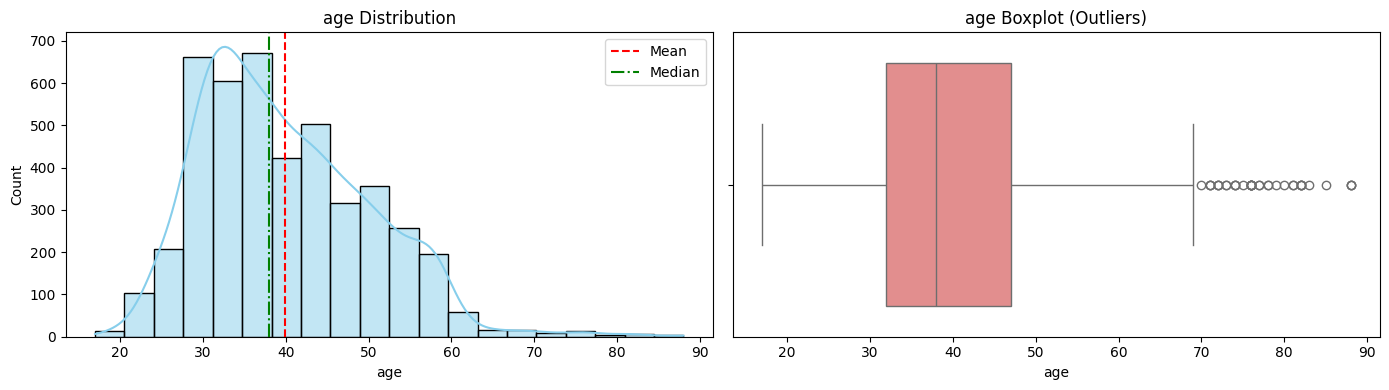

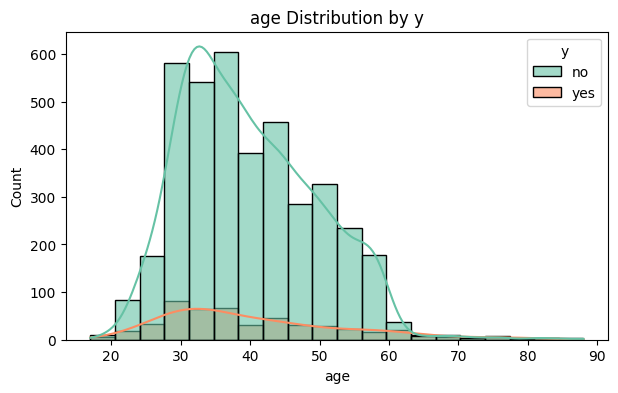

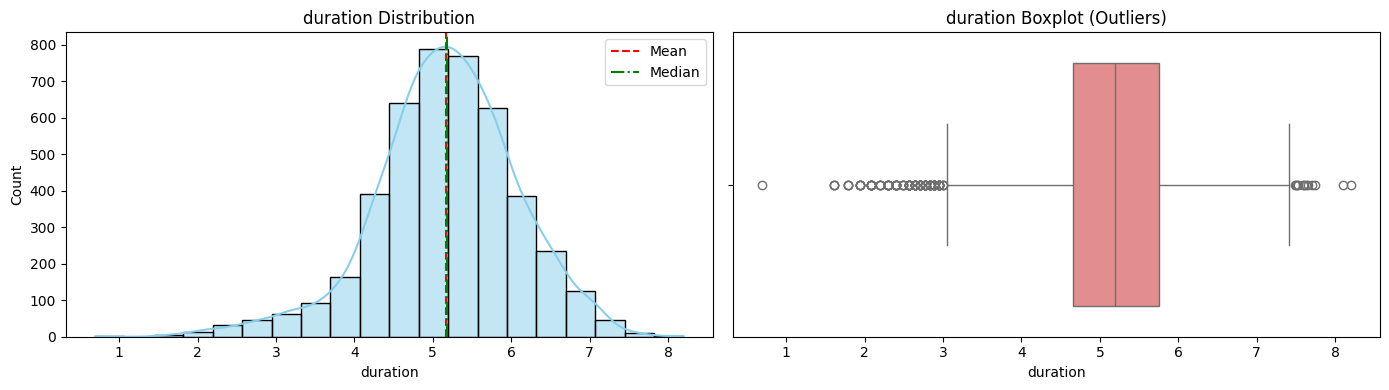

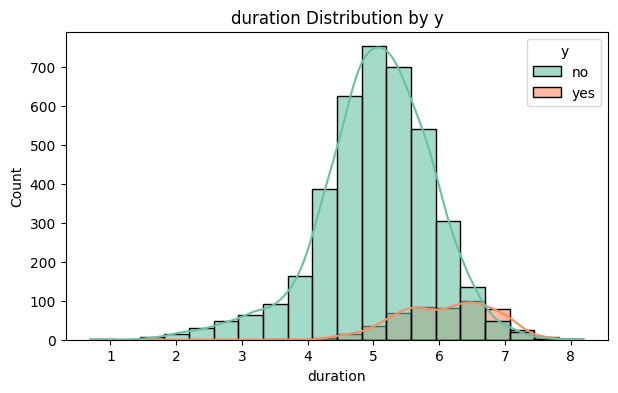

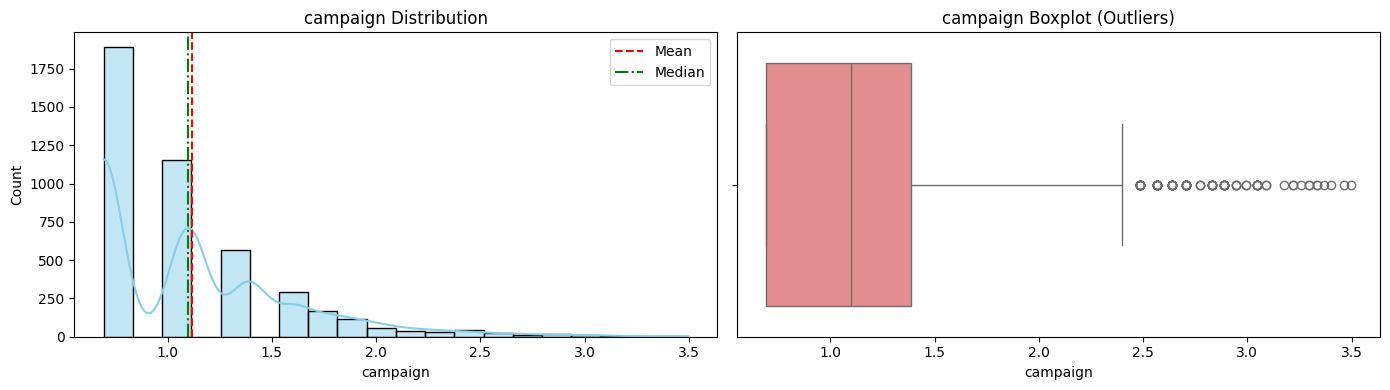

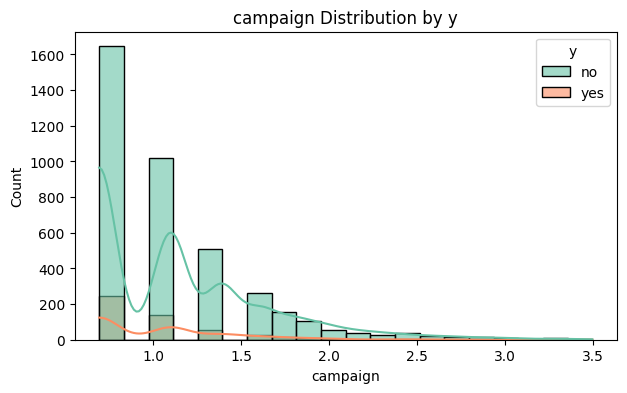

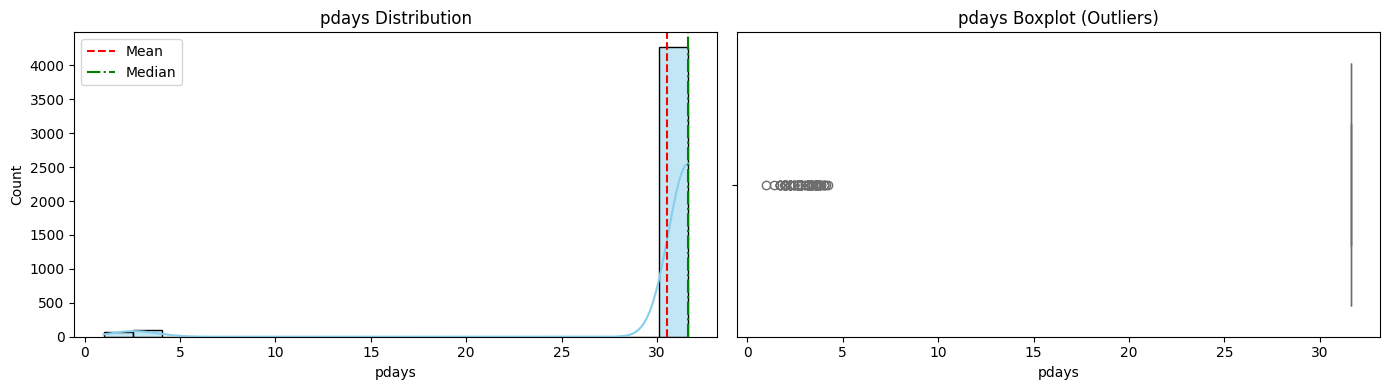

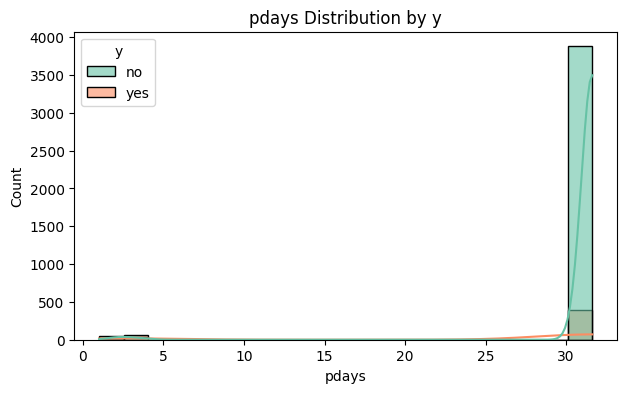

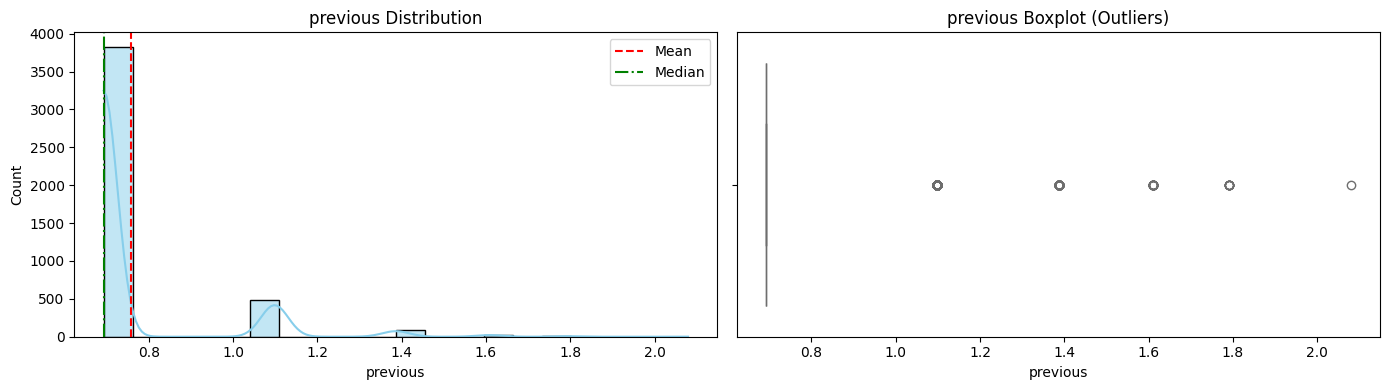

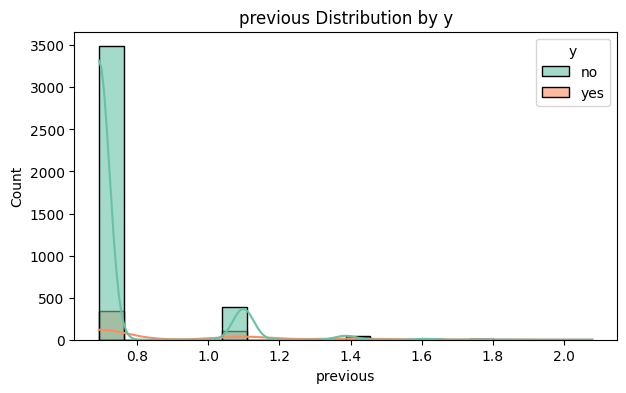

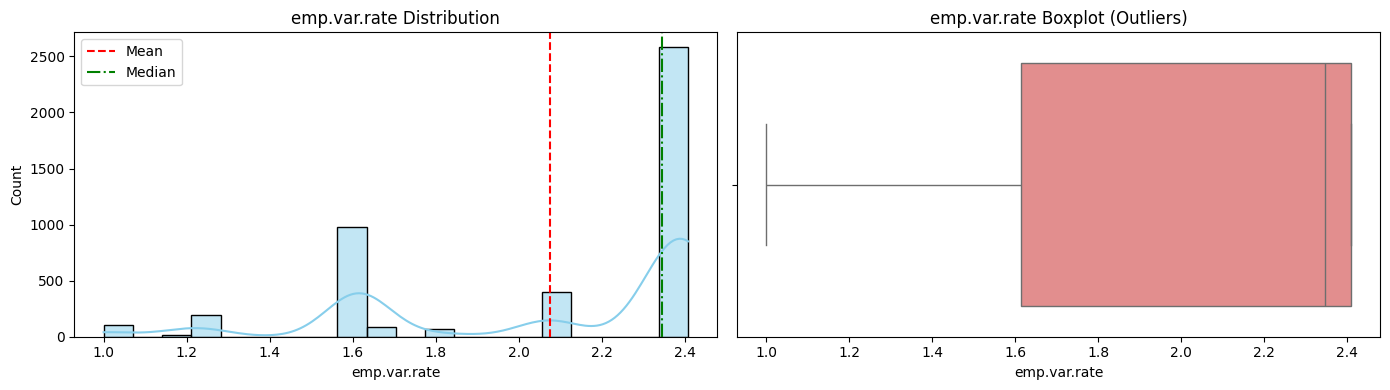

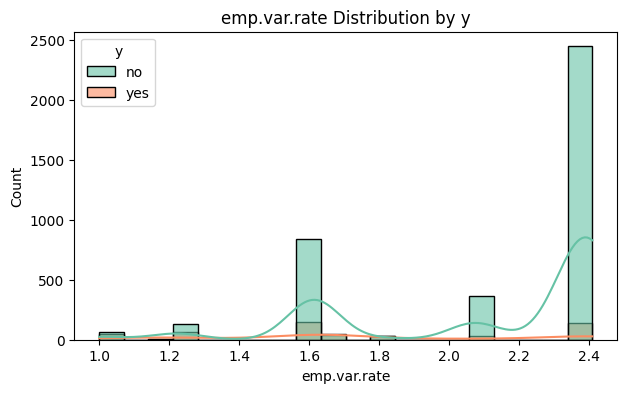

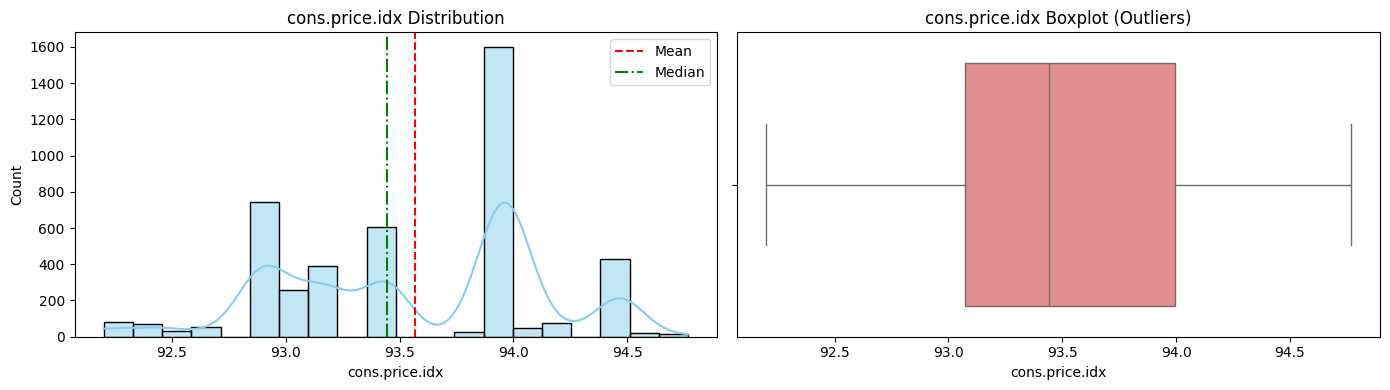

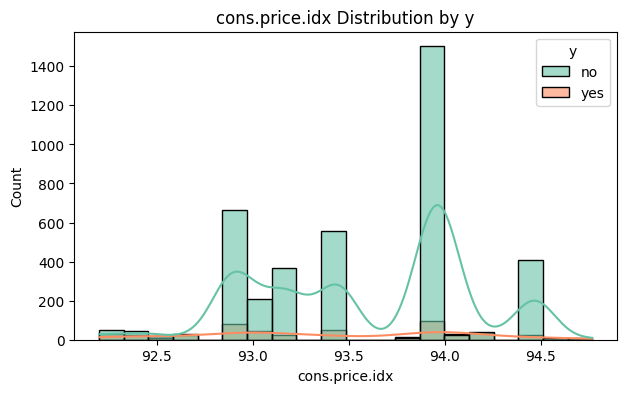

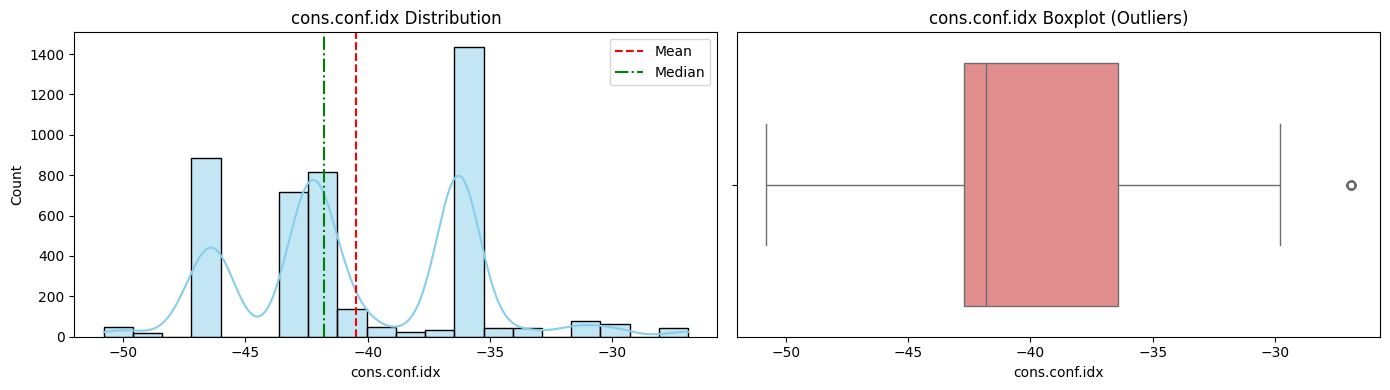

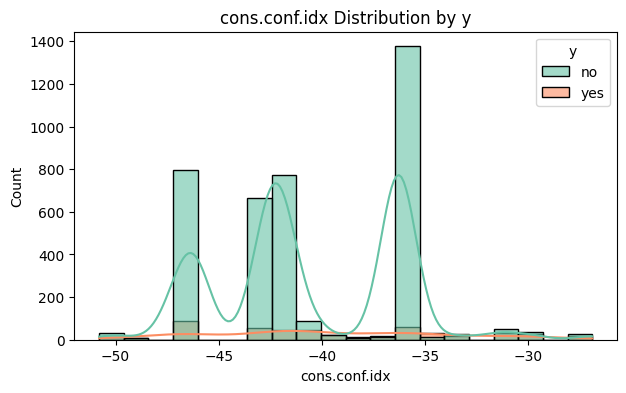

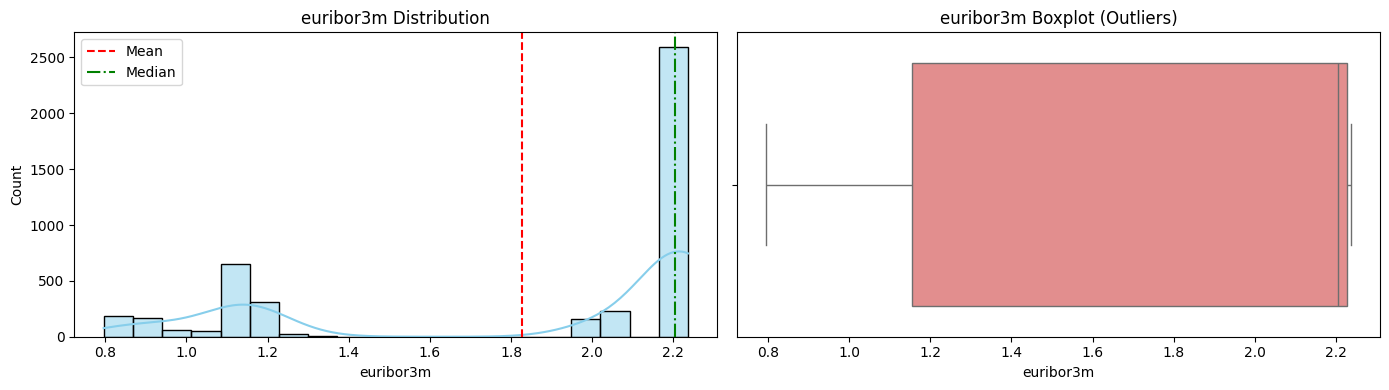

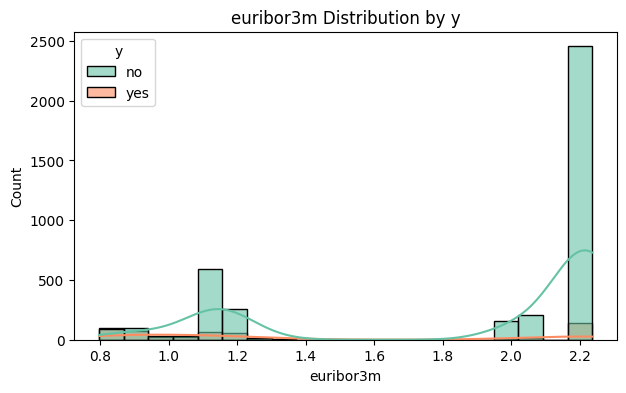

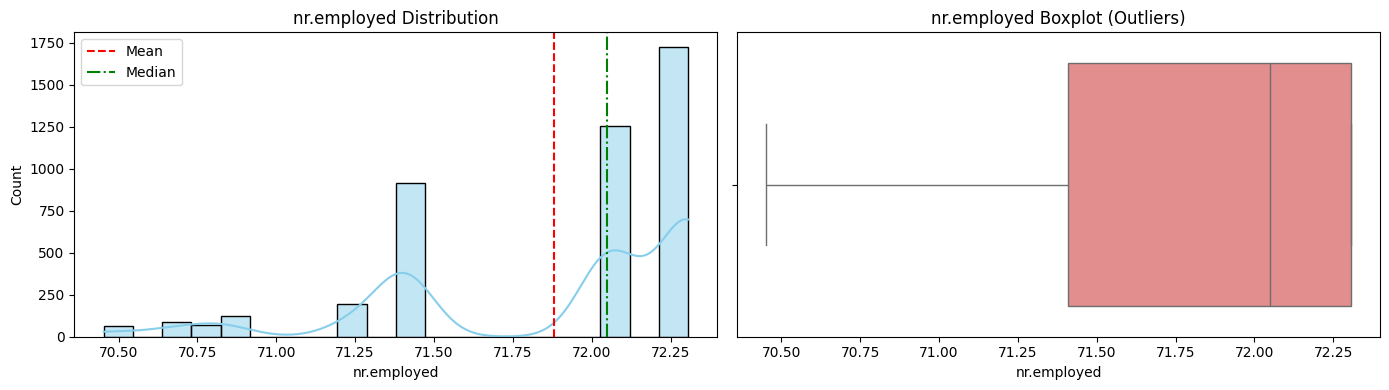

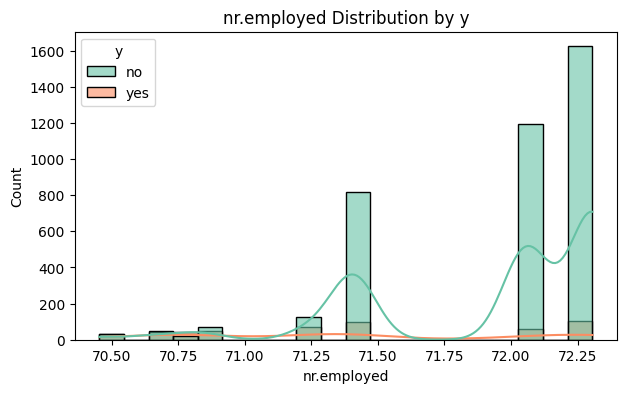

/tmp/ipython-input-2995420641.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=df_plot,


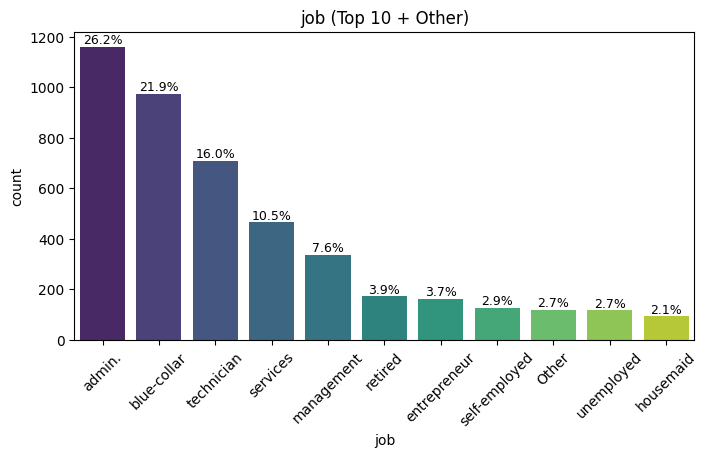

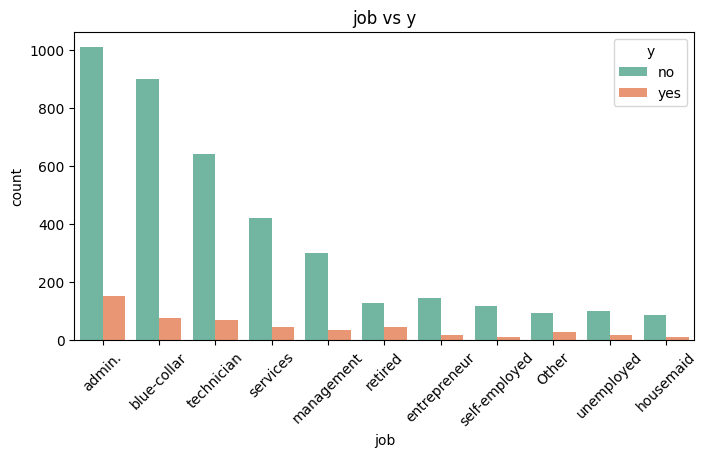

/tmp/ipython-input-2995420641.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=df_plot,


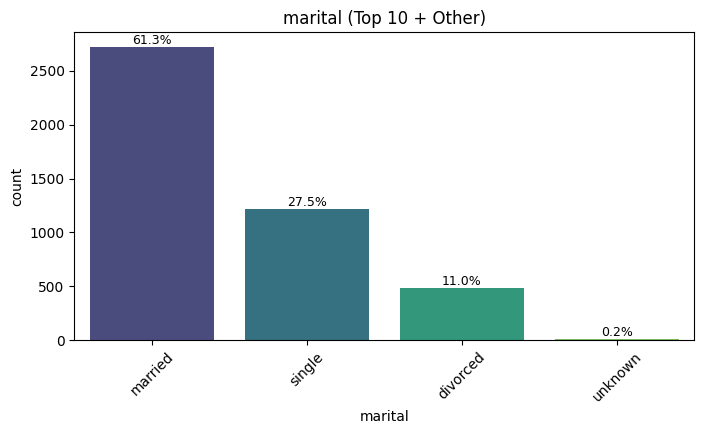

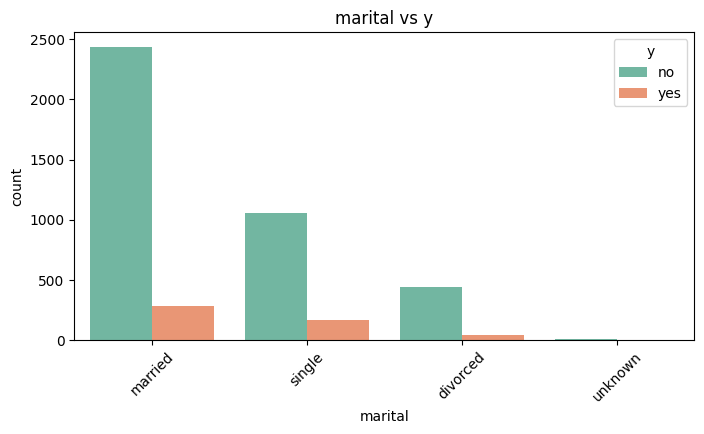

/tmp/ipython-input-2995420641.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=df_plot,


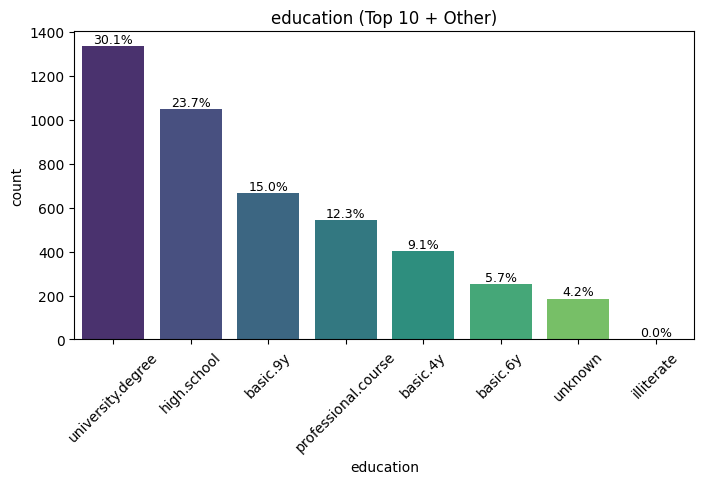

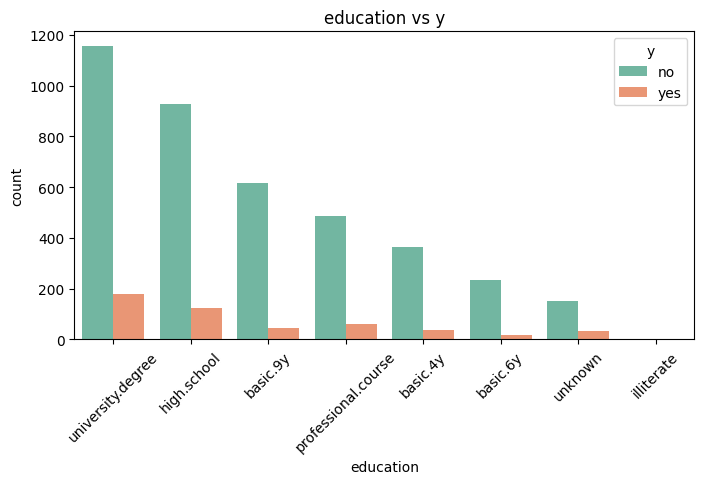

/tmp/ipython-input-2995420641.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=df_plot,


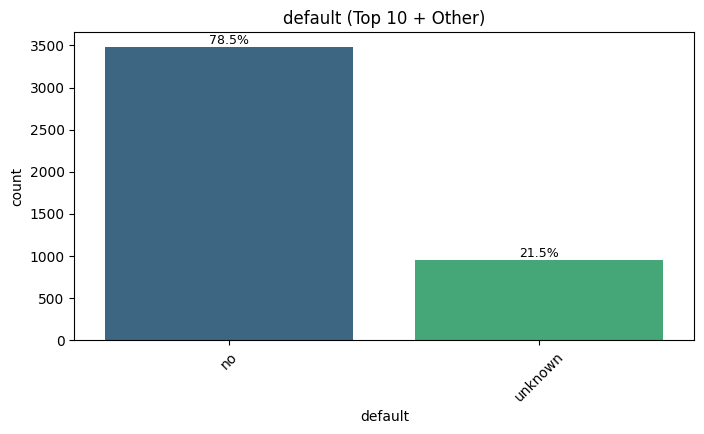

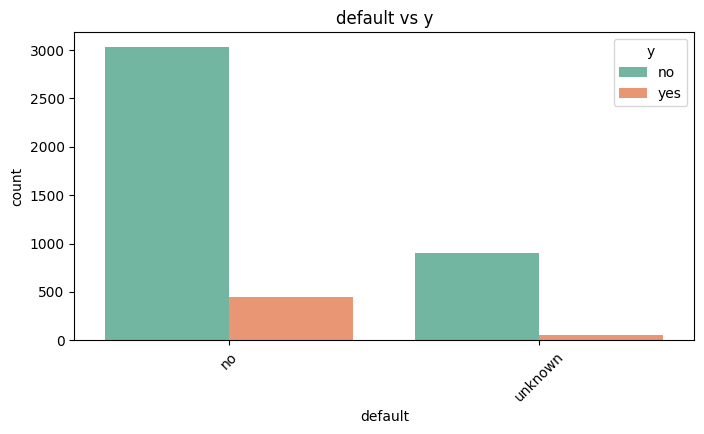

/tmp/ipython-input-2995420641.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=df_plot,


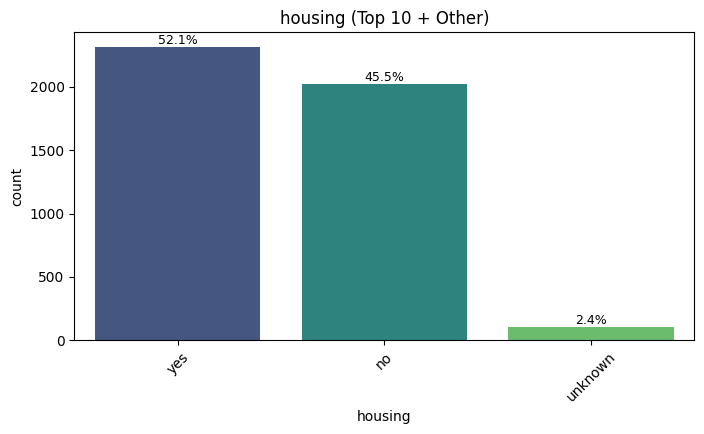

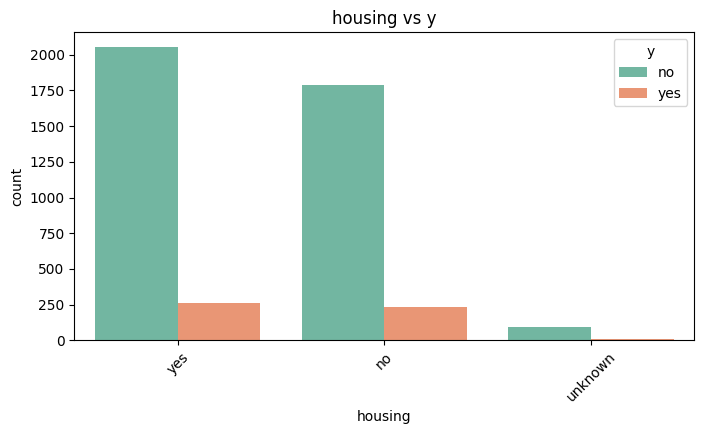

/tmp/ipython-input-2995420641.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=df_plot,


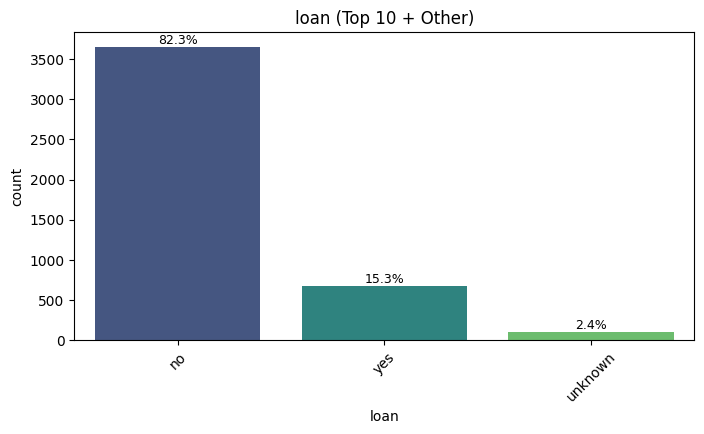

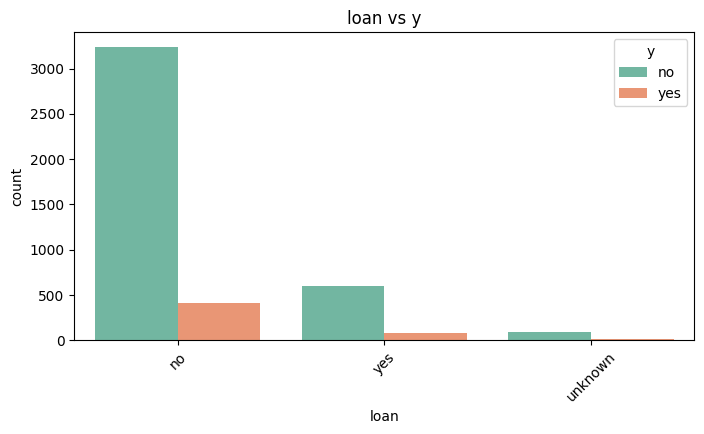

/tmp/ipython-input-2995420641.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=df_plot,


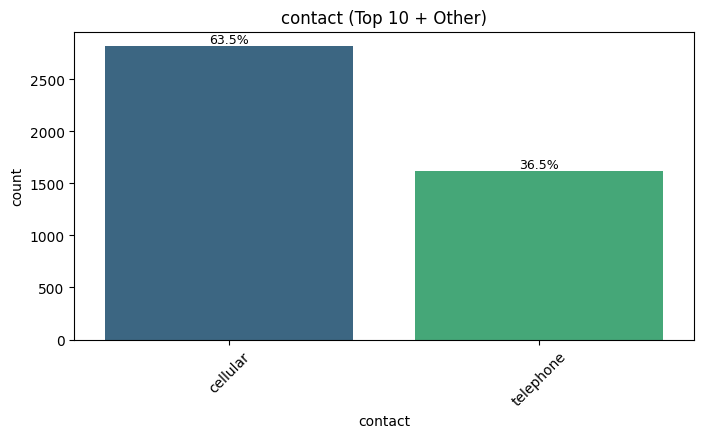

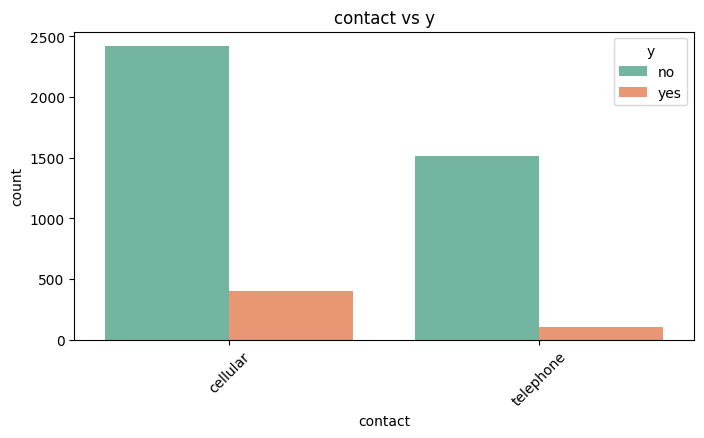

/tmp/ipython-input-2995420641.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=df_plot,


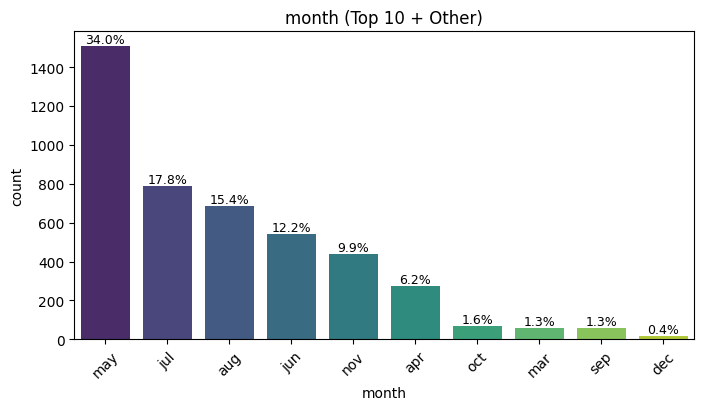

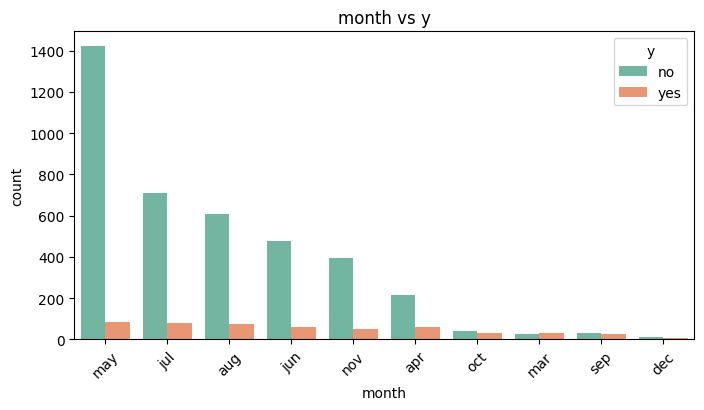

/tmp/ipython-input-2995420641.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=df_plot,


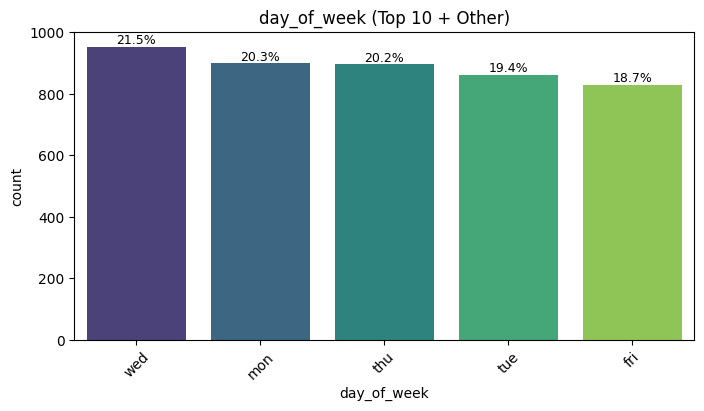

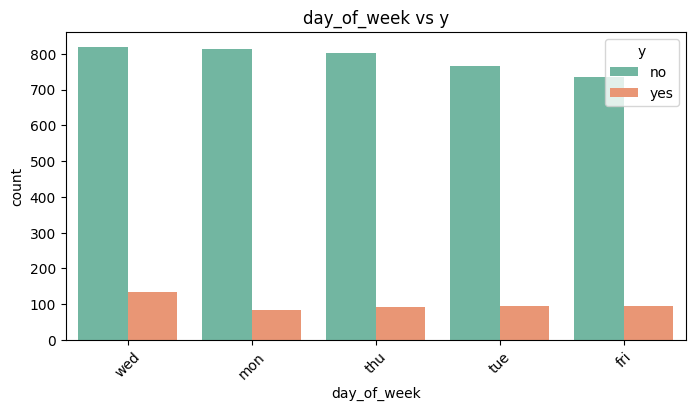

/tmp/ipython-input-2995420641.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=target_col, data=df, palette="Set2")


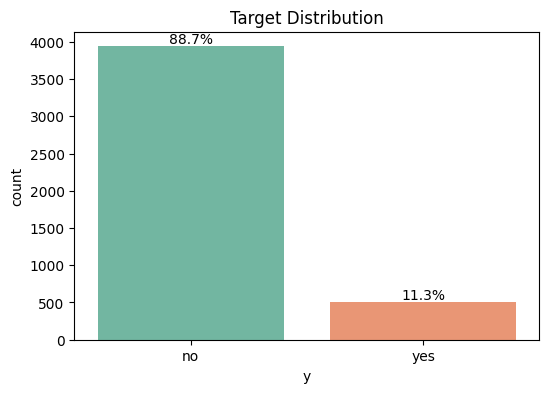

Target distribution (%):
y
no     88.73%
yes    11.27%
Name: proportion, dtype: object


In [ ]:
def plot_numeric(df, col, target_col=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(df[col], bins=20, kde=True, color='skyblue', ax=axes[0])
    axes[0].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[0].axvline(df[col].median(), color='green', linestyle='-.', label='Median')
    axes[0].set_title(f"{col} Distribution")
    axes[0].legend()

    sns.boxplot(x=df[col], color='lightcoral', ax=axes[1])
    axes[1].set_title(f"{col} Boxplot (Outliers)")

    plt.tight_layout()
    plt.show()

    if target_col:
        plt.figure(figsize=(7, 4))
        sns.histplot(data=df, x=col, hue=target_col, bins=20, kde=True,
                     palette="Set2", alpha=0.6)
        plt.title(f"{col} Distribution by {target_col}")
        plt.show()


def plot_categorical(df, col, target_col=None, top_n=10):
    top_vals = df[col].value_counts().nlargest(top_n).index
    df_plot = df.assign(**{col: df[col].where(df[col].isin(top_vals), 'Other')})

    plt.figure(figsize=(8, 4))
    ax = sns.countplot(x=col, data=df_plot,
                       palette="viridis",
                       order=df_plot[col].value_counts().index)
    plt.title(f"{col} (Top {top_n} + Other)")
    plt.xticks(rotation=45)

    total = len(df_plot)
    for p in ax.patches:
        ax.annotate(f'{p.get_height()/total:.1%}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, color='black')
    plt.show()

    if target_col:
        plt.figure(figsize=(8, 4))
        sns.countplot(x=col, hue=target_col, data=df_plot,
                      palette="Set2",
                      order=df_plot[col].value_counts().index)
        plt.title(f"{col} vs {target_col}")
        plt.xticks(rotation=45)
        plt.show()


def plot_target(df, target_col):
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(x=target_col, data=df, palette="Set2")
    plt.title("Target Distribution")

    total = len(df)
    for p in ax.patches:
        ax.annotate(f'{p.get_height()/total:.1%}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10)
    plt.show()

    print("Target distribution (%):")
    print(df[target_col].value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))

for col in num_cols:
    plot_numeric(df_capped, col, target_col=target_col)

for col in cat_cols:
    plot_categorical(df_capped, col, target_col=target_col)

plot_target(df_capped, target_col)

/tmp/ipython-input-361111005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y=col, data=df, palette="Set3", inner=None)


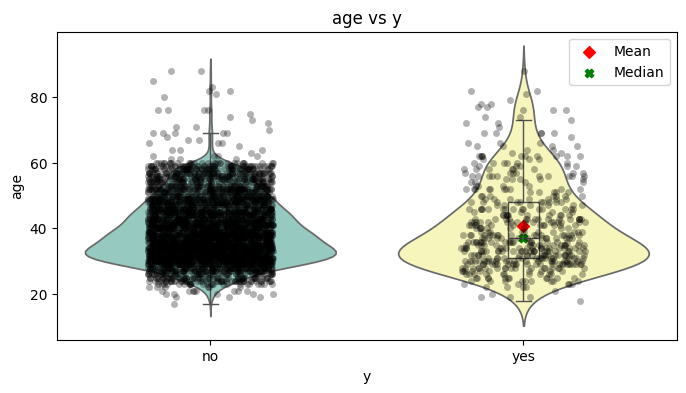

/tmp/ipython-input-361111005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y=col, data=df, palette="Set3", inner=None)


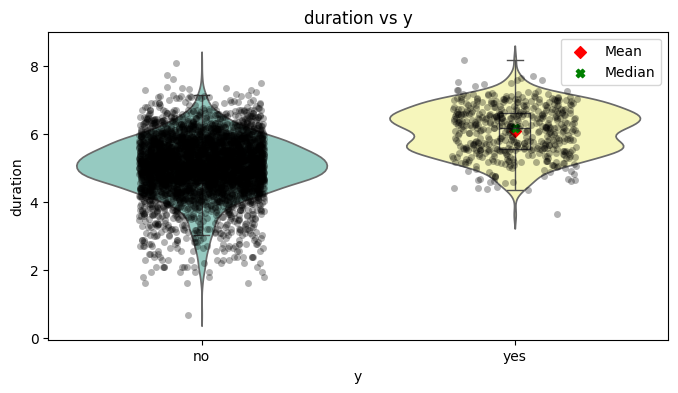

/tmp/ipython-input-361111005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y=col, data=df, palette="Set3", inner=None)


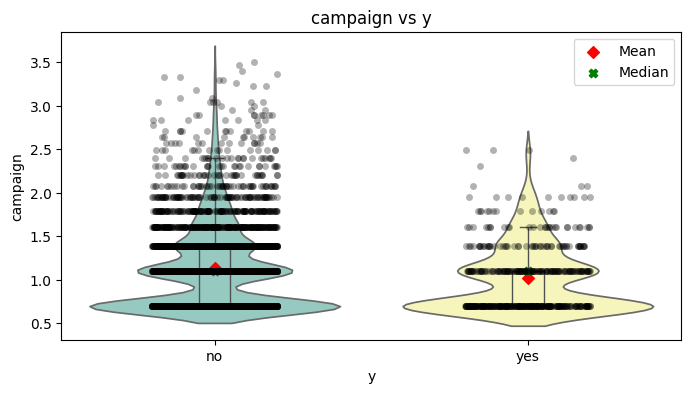

/tmp/ipython-input-361111005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y=col, data=df, palette="Set3", inner=None)


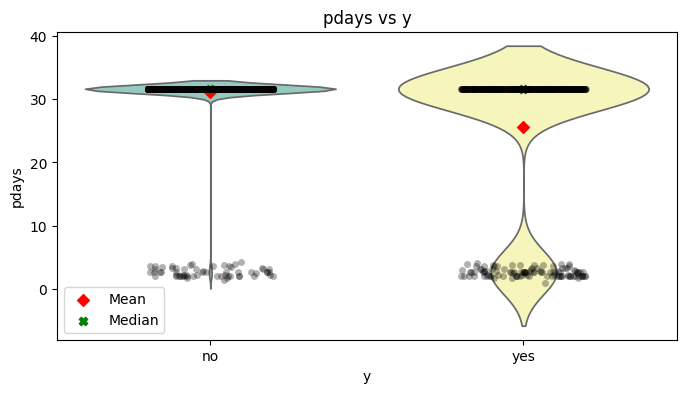

/tmp/ipython-input-361111005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y=col, data=df, palette="Set3", inner=None)


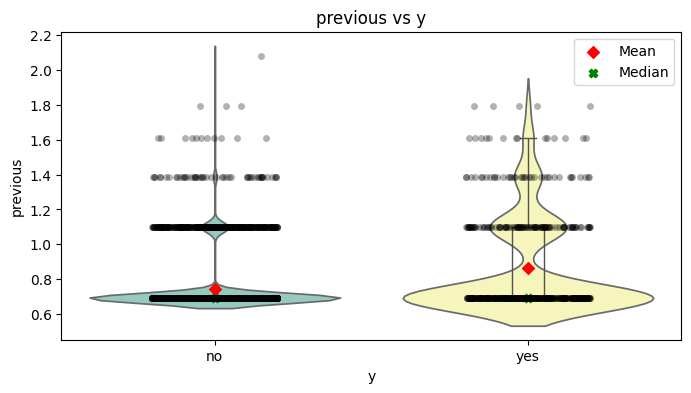

/tmp/ipython-input-361111005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y=col, data=df, palette="Set3", inner=None)


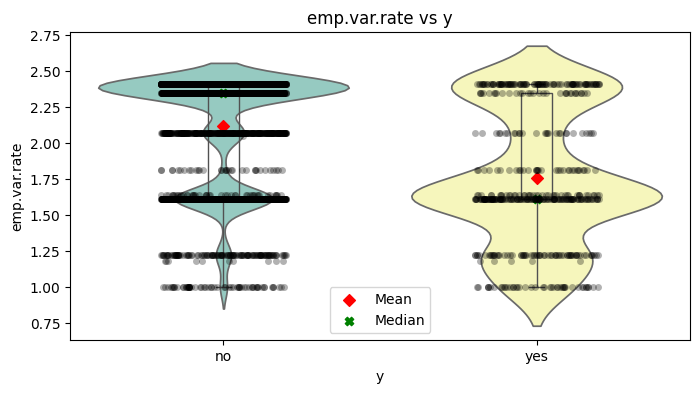

/tmp/ipython-input-361111005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y=col, data=df, palette="Set3", inner=None)


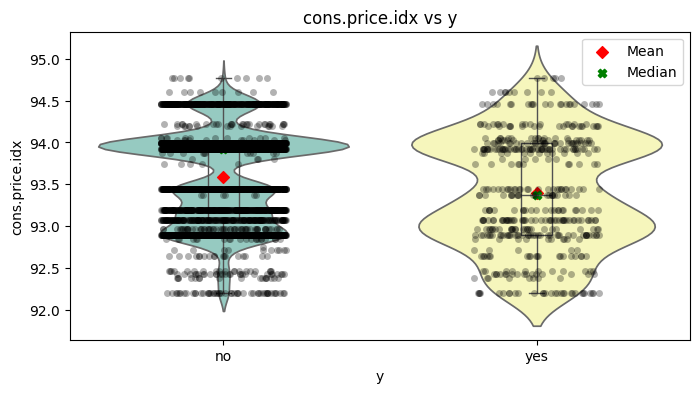

/tmp/ipython-input-361111005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y=col, data=df, palette="Set3", inner=None)


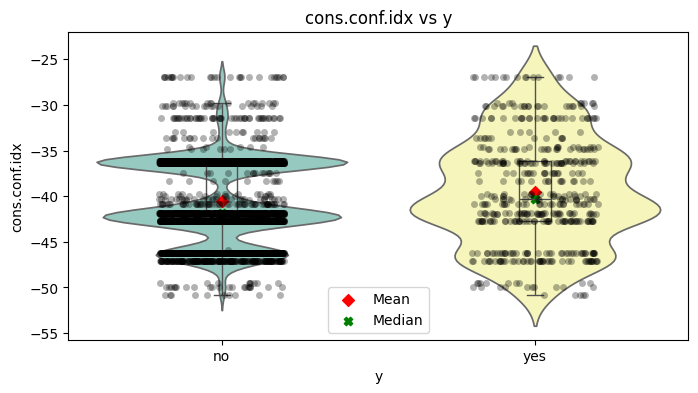

/tmp/ipython-input-361111005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y=col, data=df, palette="Set3", inner=None)


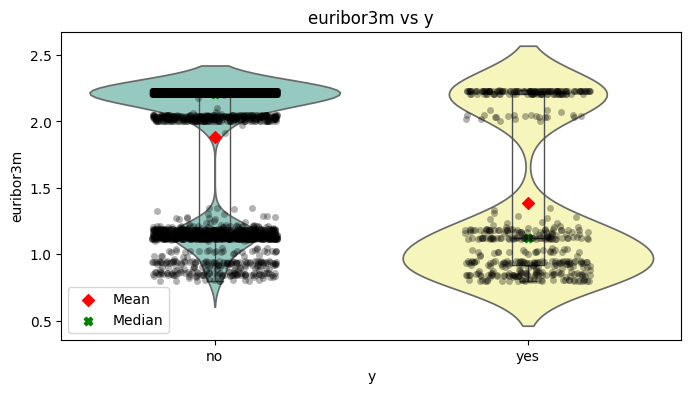

/tmp/ipython-input-361111005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y=col, data=df, palette="Set3", inner=None)


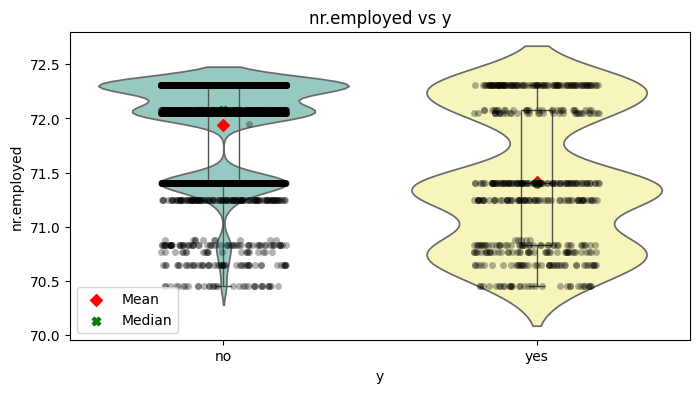

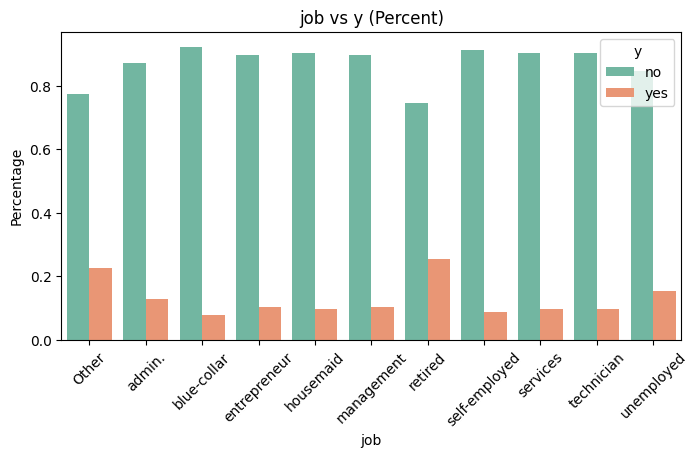

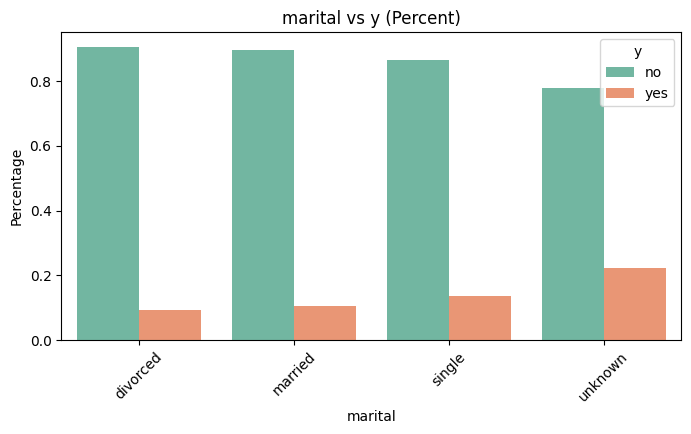

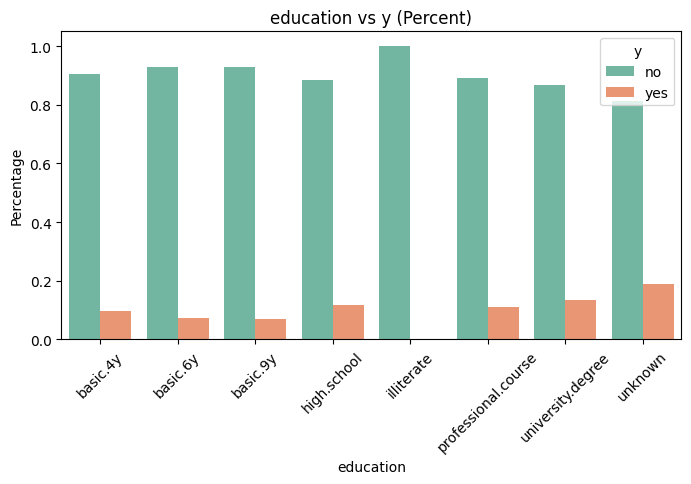

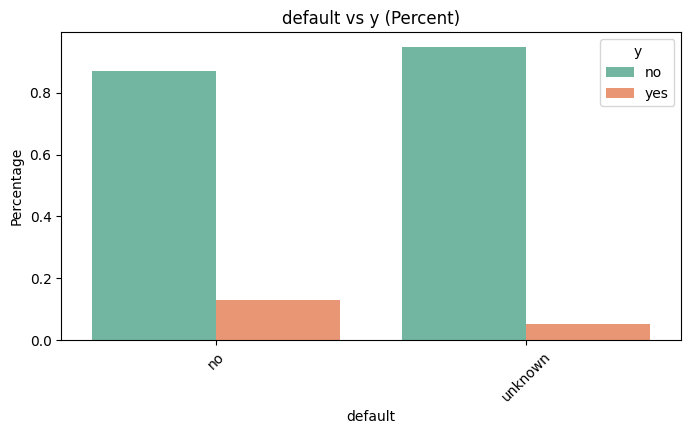

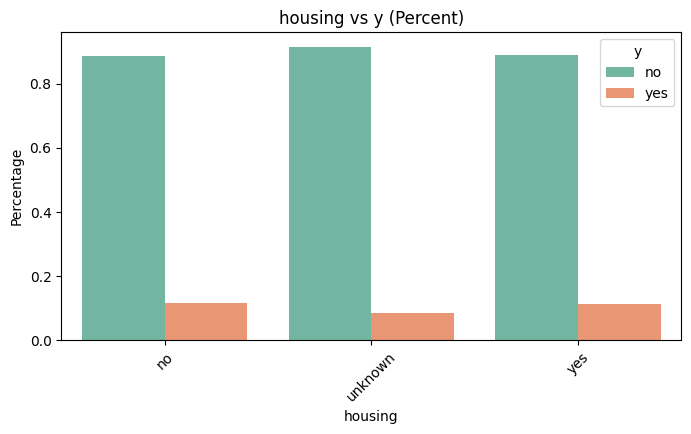

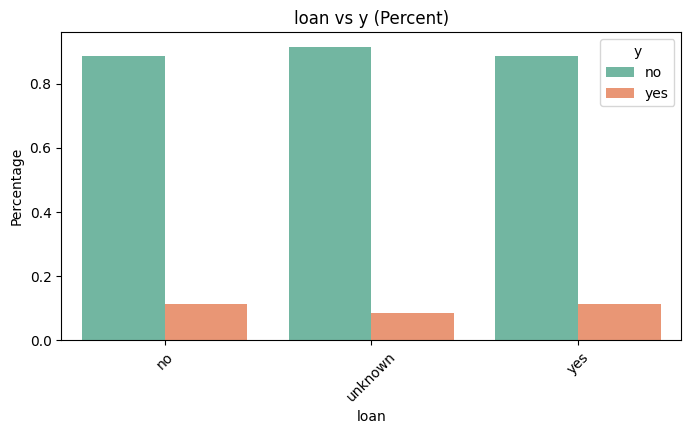

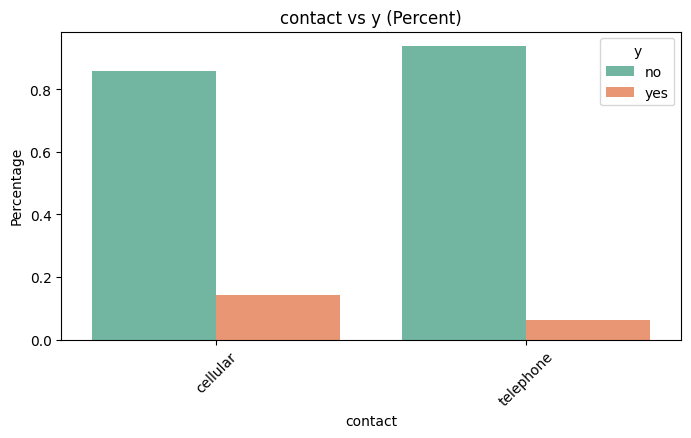

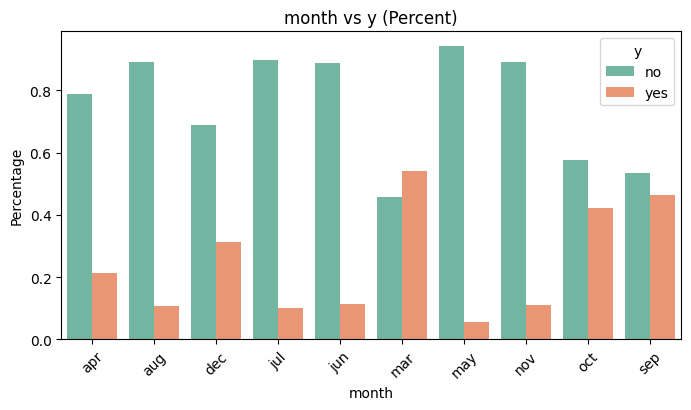

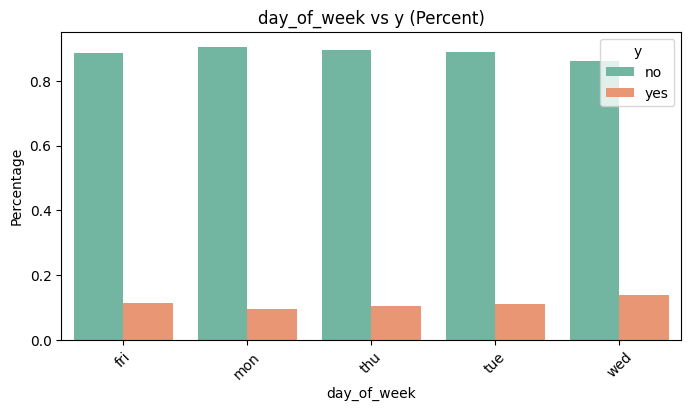

In [ ]:
def plot_numeric_vs_target(df, col, target_col):
    plt.figure(figsize=(8, 4))

    sns.violinplot(x=target_col, y=col, data=df, palette="Set3", inner=None)
    sns.boxplot(x=target_col, y=col, data=df, width=0.1, showcaps=True,
                boxprops={'facecolor':'none'}, showfliers=False)
    sns.stripplot(x=target_col, y=col, data=df, color='black', alpha=0.3, jitter=0.2)

    stats = df.groupby(target_col)[col].agg(["mean", "median"])
    for j, cls in enumerate(stats.index):
        plt.scatter(j, stats.loc[cls, "mean"], color='red', marker='D', label='Mean' if j == 0 else "")
        plt.scatter(j, stats.loc[cls, "median"], color='green', marker='X', label='Median' if j == 0 else "")

    plt.title(f"{col} vs {target_col}")
    plt.legend()
    plt.show()

def plot_categorical_vs_target(df, col, target_col, top_n=10):
    if df[col].nunique() <= 1:
        return

    top_vals = df[col].value_counts().nlargest(top_n).index
    df_plot = df.assign(**{col: df[col].where(df[col].isin(top_vals), 'Other')})

    prop_df = (
        df_plot.groupby([col, target_col])
        .size()
        .reset_index(name="count")
    )
    prop_df["percent"] = prop_df.groupby(col)["count"].transform(lambda x: x / x.sum())

    plt.figure(figsize=(8, 4))
    sns.barplot(x=col, y="percent", hue=target_col, data=prop_df, palette="Set2")
    plt.title(f"{col} vs {target_col} (Percent)")
    plt.xticks(rotation=45)
    plt.ylabel("Percentage")
    plt.show()

for col in num_cols:
    plot_numeric_vs_target(df_capped, col, target_col)

for col in cat_cols:
    plot_categorical_vs_target(df_capped, col, target_col)

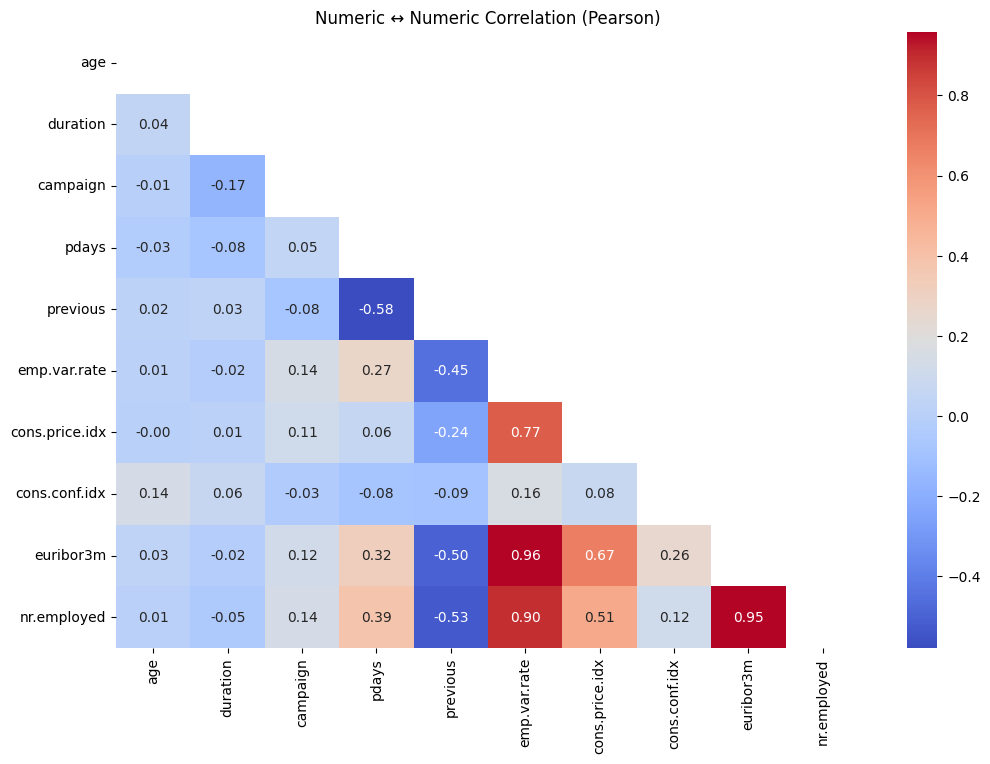


Strong Numeric ↔ Numeric Correlations (>0.7):
emp.var.rate  euribor3m         0.958413
euribor3m     nr.employed       0.953085
emp.var.rate  nr.employed       0.897045
              cons.price.idx    0.772891
dtype: float64


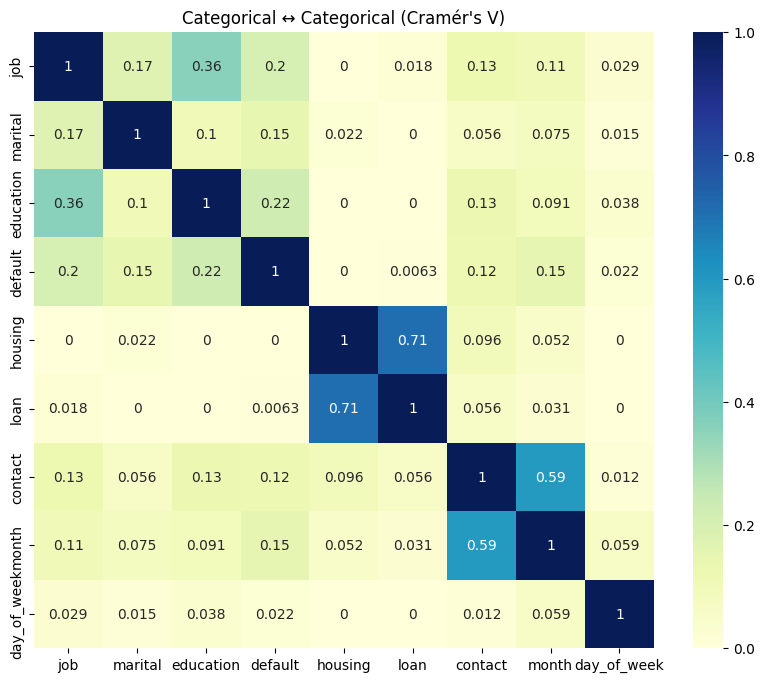


Strong Categorical ↔ Categorical Associations (Cramér's V > 0.3):


,Feature 1,Feature 2,Cramers_V
26,housing,loan,0.708019
33,contact,month,0.593830
1,job,education,0.359354



Numeric ↔ Target (Point-Biserial), sorted by |Correlation|:


,Feature,Correlation,p-value,abs_corr
1,duration,0.367837,2.985372e-142,0.367837
9,nr.employed,-0.332039,1.078736e-114,0.332039
3,pdays,-0.325687,3.582157e-110,0.325687
8,euribor3m,-0.292892,1.640924e-88,0.292892
5,emp.var.rate,-0.274701,1.151293e-77,0.274701
4,previous,0.217296,1.404999e-48,0.217296
6,cons.price.idx,-0.108003,5.431792e-13,0.108003
2,campaign,-0.075912,4.126722e-07,0.075912
7,cons.conf.idx,0.071654,1.767884e-06,0.071654
0,age,0.028898,5.422969e-02,0.028898



Categorical ↔ Target (Chi-Square Test), sorted by p-value:


,Feature,Chi2,p-value
7,month,330.975539,6.899820e-66
6,contact,65.085125,7.173151e-16
0,job,90.317632,1.444530e-14
3,default,43.643073,3.940695e-11
2,education,34.092142,1.655403e-05
1,marital,10.874489,1.242429e-02
8,day_of_week,10.602505,3.141392e-02
4,housing,0.877118,6.449651e-01
5,loan,0.781771,6.764577e-01


In [ ]:
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.preprocessing import LabelEncoder

# ====================================================
# Advanced Correlation Analysis (Fintech-Optimized)
# ====================================================

# ✅ Convert target to numeric if needed
if df_capped[target_col].dtype == "object":
    le = LabelEncoder()
    df_capped[target_col] = le.fit_transform(df_capped[target_col])

# -------------------------
# 1️⃣ Numeric ↔ Numeric (Pearson)
# -------------------------
num_cols_corr = [col for col in num_cols if df_capped[col].nunique() > 1]

if num_cols_corr:
    corr_matrix = df_capped[num_cols_corr].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", mask=mask)
    plt.title("Numeric ↔ Numeric Correlation (Pearson)")
    plt.show()

    strong_corrs = (
        corr_matrix.abs().unstack()
        .drop_duplicates()
        .sort_values(ascending=False)
    )
    strong_corrs = strong_corrs[(strong_corrs < 1) & (strong_corrs > 0.7)]
    if not strong_corrs.empty:
        print("\nStrong Numeric ↔ Numeric Correlations (>0.7):")
        print(strong_corrs)
else:
    print("\n⚠️ No valid numeric columns for Pearson correlation.")

# -------------------------
# 2️⃣ Categorical ↔ Categorical (Cramér's V)
# -------------------------
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min(kcorr-1, rcorr-1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

if cat_cols:
    # Compute full matrix
    cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
    for i, col1 in enumerate(cat_cols):
        for j, col2 in enumerate(cat_cols):
            if i <= j:
                cramers_matrix.loc[col1, col2] = 1.0 if i == j else cramers_v(df_capped[col1], df_capped[col2])
            else:
                cramers_matrix.loc[col1, col2] = cramers_matrix.loc[col2, col1]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cramers_matrix, annot=True, cmap="YlGnBu")
    plt.title("Categorical ↔ Categorical (Cramér's V)")
    plt.show()

    # Extract strong associations into a table
    strong_cat = (
        cramers_matrix.where(np.triu(np.ones(cramers_matrix.shape), k=1).astype(bool))
        .stack()
        .reset_index()
        .rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: "Cramers_V"})
    )
    strong_cat = strong_cat[strong_cat["Cramers_V"] > 0.3].sort_values("Cramers_V", ascending=False)

    if not strong_cat.empty:
        print("\nStrong Categorical ↔ Categorical Associations (Cramér's V > 0.3):")
        display(strong_cat)
    else:
        print("\n⚠️ No strong categorical associations above 0.3.")
else:
    print("\n⚠️ No categorical columns for Cramér’s V.")

# -------------------------
# 3️⃣ Numeric ↔ Target (Point-Biserial)
# -------------------------
pb_results = []
for col in num_cols_corr:
    try:
        corr, pval = pointbiserialr(df_capped[col], df_capped[target_col])
        pb_results.append({"Feature": col, "Correlation": corr, "p-value": pval})
    except Exception as e:
        pb_results.append({"Feature": col, "Correlation": np.nan, "p-value": np.nan})

if pb_results:
    pb_df = pd.DataFrame(pb_results)
    pb_df["abs_corr"] = pb_df["Correlation"].abs()
    pb_df_sorted = pb_df.sort_values("abs_corr", ascending=False)
    print("\nNumeric ↔ Target (Point-Biserial), sorted by |Correlation|:")
    display(pb_df_sorted)
else:
    print("\n⚠️ No numeric features for Point-Biserial correlation.")

# -------------------------
# 4️⃣ Categorical ↔ Target (Chi-Square)
# -------------------------
chi2_results = []
for col in cat_cols:
    if df_capped[col].nunique() > 1:
        contingency = pd.crosstab(df_capped[col], df_capped[target_col])
        chi2, p, _, _ = chi2_contingency(contingency)
        chi2_results.append({"Feature": col, "Chi2": chi2, "p-value": p})

if chi2_results:
    chi2_df = pd.DataFrame(chi2_results).sort_values("p-value")
    print("\nCategorical ↔ Target (Chi-Square Test), sorted by p-value:")
    display(chi2_df)
else:
    print("\n⚠️ No categorical columns for Chi-Square test.")

In [ ]:
df_fe = df_knn_clean.copy()

In [ ]:
unique_classes = sorted(df_fe[target_col].unique())
class_mapping = {cls: idx for idx, cls in enumerate(unique_classes)}
df_fe[target_col] = df_fe[target_col].map(class_mapping)
print("Target classes after mapping:", df_fe[target_col].unique())

features = df_fe.drop(columns=[target_col]).copy()

binary_cols = []
multiclass_cols = []
numeric_binary_cols = []

for col in features.columns:
    n_unique = features[col].nunique()
    dtype = features[col].dtype

    if dtype == "object" or dtype.name == "category":
        if n_unique == 2:
            binary_cols.append(col)
        elif n_unique > 2:
            multiclass_cols.append(col)
    elif np.issubdtype(dtype, np.number):
        if n_unique == 2:
            numeric_binary_cols.append(col)

for col in binary_cols:
    sorted_vals = sorted(features[col].unique())
    mapping = {v: i for i, v in enumerate(sorted_vals)}
    features[col] = features[col].map(mapping)

for col in numeric_binary_cols:
    sorted_vals = sorted(features[col].unique())
    mapping = {v: i for i, v in enumerate(sorted_vals)}
    features[col] = features[col].map(mapping)

features = pd.get_dummies(features, columns=multiclass_cols, drop_first=True)

df_encoded = features.copy()
df_encoded[target_col] = df_fe[target_col]

print("Encoded dataset shape:", df_encoded.shape)
df_encoded.head()

Target classes after mapping: [0 1]
Encoded dataset shape: (4438, 53)


,age,default,contact,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,y
4155,24.0,0,1,5.273000,1.098612,31.622777,0.693147,2.345208,93.994,-36.4,...,False,False,False,True,False,False,False,True,False,0
6627,37.0,0,1,4.430817,1.098612,31.622777,0.693147,2.345208,93.994,-36.4,...,False,False,False,False,False,False,True,True,False,0
30628,44.0,0,0,5.442418,1.945910,3.605551,1.098612,1.612452,92.893,-46.2,...,False,False,False,True,False,False,False,False,True,0
33335,33.0,0,0,5.347108,0.693147,31.622777,0.693147,1.612452,92.893,-46.2,...,False,False,False,False,False,True,False,True,False,0
34134,40.0,1,0,6.656727,1.098612,31.622777,0.693147,1.612452,92.893,-46.2,...,False,False,False,False,False,False,True,True,False,0


In [ ]:
from sklearn.preprocessing import RobustScaler

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

df_scaled = pd.concat([X_scaled, y], axis=1)

df_scaled.head()

,age,default,contact,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,y
4155,-0.933333,0.0,1.0,0.077483,0.000000,0.000000,0.000000,0.000000,0.598477,0.857143,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
6627,-0.066667,0.0,1.0,-0.684714,0.000000,0.000000,0.000000,0.000000,0.598477,0.857143,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
30628,0.400000,0.0,0.0,0.230810,1.222392,-28.017225,0.405465,-0.920702,-0.599565,-0.698413,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.0,1.0,0
33335,-0.333333,0.0,0.0,0.144552,-0.584963,0.000000,0.000000,-0.920702,-0.599565,-0.698413,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
34134,0.133333,1.0,0.0,1.329791,0.000000,0.000000,0.000000,-0.920702,-0.599565,-0.698413,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [ ]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4438 entries, 4155 to 15394
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            4438 non-null   float64
 1   default                        4438 non-null   float64
 2   contact                        4438 non-null   float64
 3   duration                       4438 non-null   float64
 4   campaign                       4438 non-null   float64
 5   pdays                          4438 non-null   float64
 6   previous                       4438 non-null   float64
 7   emp.var.rate                   4438 non-null   float64
 8   cons.price.idx                 4438 non-null   float64
 9   cons.conf.idx                  4438 non-null   float64
 10  euribor3m                      4438 non-null   float64
 11  nr.employed                    4438 non-null   float64
 12  job_blue-collar                4438 non-null   fl

In [ ]:
def safe_feature_interactions(df, target_col, top_features=10, top_interactions=10):
    import itertools
    from sklearn.feature_selection import mutual_info_classif
    import numpy as np
    import pandas as pd

    # -----------------------------
    # Detect categorical vs numeric
    # -----------------------------
    # Treat any column with <= 10 unique values (excluding target) as categorical
    categorical_cols = [
        c for c in df.columns
        if c != target_col and df[c].nunique() <= 10
    ]
    numeric_cols = [c for c in df.columns if c not in categorical_cols + [target_col]]

    # -----------------------------
    # Step 1: top features by MI
    # -----------------------------
    all_features = categorical_cols + numeric_cols
    mi_scores = mutual_info_classif(
        df[all_features], df[target_col],
        discrete_features=[f in categorical_cols for f in all_features],
        random_state=42
    )
    mi_df = pd.DataFrame({"Feature": all_features, "MI_Score": mi_scores}).sort_values("MI_Score", ascending=False)

    selected_features = mi_df.head(top_features)["Feature"].tolist()
    selected_categorical = [f for f in selected_features if f in categorical_cols]
    selected_numeric = [f for f in selected_features if f in numeric_cols]

    # -----------------------------
    # Step 2: generate interactions
    # -----------------------------
    interactions = {}

    # Categorical × Categorical (treat as binary-like, just multiply codes)
    for f1, f2 in itertools.combinations(selected_categorical, 2):
        interactions[f"{f1}_x_{f2}"] = df[f1] * df[f2]

    # Numeric × Categorical
    for num_col in selected_numeric:
        for cat_col in selected_categorical:
            interactions[f"{num_col}_x_{cat_col}"] = df[num_col] * df[cat_col]

    if not interactions:
        print("⚠️ No interactions generated.")
        return df.copy(), []

    df_interactions = pd.DataFrame(interactions)

    # -----------------------------
    # Step 3: select top interactions
    # -----------------------------
    mi_scores_interactions = mutual_info_classif(
        df_interactions, df[target_col],
        discrete_features=[col in selected_categorical for col in df_interactions.columns],
        random_state=42
    )
    mi_inter_df = pd.DataFrame({"Feature": df_interactions.columns, "MI_Score": mi_scores_interactions})
    mi_inter_df = mi_inter_df.sort_values("MI_Score", ascending=False)

    top_interaction_names = mi_inter_df.head(top_interactions)["Feature"].tolist()
    df_top_interactions = df_interactions[top_interaction_names]

    # -----------------------------
    # Step 4: merge back
    # -----------------------------
    df_model_ready = pd.concat([df, df_top_interactions], axis=1)

    return df_model_ready, top_interaction_names


# ==========================
# Run the safe interaction pipeline
# ==========================
df_model_ready, added_interactions = safe_feature_interactions(
    df_scaled, target_col=target_col,
    top_features=10, top_interactions=10
)

print(f"Original shape: {df_scaled.shape}")
print(f"New shape with top interactions: {df_model_ready.shape}")
print("Top interactions added:")
print(added_interactions)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)


Original shape: (4438, 53)
New shape with top interactions: (4438, 63)
Top interactions added:
['duration_x_emp.var.rate', 'cons.conf.idx_x_emp.var.rate', 'euribor3m_x_emp.var.rate', 'cons.price.idx_x_emp.var.rate', 'nr.employed_x_emp.var.rate', 'pdays_x_emp.var.rate', 'nr.employed_x_poutcome_nonexistent', 'duration_x_previous', 'nr.employed_x_poutcome_success', 'duration_x_poutcome_success']


In [ ]:
df_model_ready.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4438 entries, 4155 to 15394
Data columns (total 63 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   age                                 4438 non-null   float64
 1   default                             4438 non-null   float64
 2   contact                             4438 non-null   float64
 3   duration                            4438 non-null   float64
 4   campaign                            4438 non-null   float64
 5   pdays                               4438 non-null   float64
 6   previous                            4438 non-null   float64
 7   emp.var.rate                        4438 non-null   float64
 8   cons.price.idx                      4438 non-null   float64
 9   cons.conf.idx                       4438 non-null   float64
 10  euribor3m                           4438 non-null   float64
 11  nr.employed                         4438 non

In [ ]:
X = df_model_ready.drop(columns=[target_col])
y = df_model_ready[target_col]

In [ ]:
X.head()

,age,default,contact,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,...,duration_x_emp.var.rate,cons.conf.idx_x_emp.var.rate,euribor3m_x_emp.var.rate,cons.price.idx_x_emp.var.rate,nr.employed_x_emp.var.rate,pdays_x_emp.var.rate,nr.employed_x_poutcome_nonexistent,duration_x_previous,nr.employed_x_poutcome_success,duration_x_poutcome_success
4155,-0.933333,0.0,1.0,0.077483,0.000000,0.000000,0.000000,0.000000,0.598477,0.857143,...,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
6627,-0.066667,0.0,1.0,-0.684714,0.000000,0.000000,0.000000,0.000000,0.598477,0.857143,...,-0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,-0.000000,0.000000,-0.00000
30628,0.400000,0.0,0.0,0.230810,1.222392,-28.017225,0.405465,-0.920702,-0.599565,-0.698413,...,-0.212507,0.64303,0.894045,0.55202,0.657086,25.795503,0.713679,0.093586,-0.713679,0.23081
33335,-0.333333,0.0,0.0,0.144552,-0.584963,0.000000,0.000000,-0.920702,-0.599565,-0.698413,...,-0.133089,0.64303,0.917588,0.55202,0.657086,-0.000000,-0.000000,0.000000,-0.000000,0.00000
34134,0.133333,1.0,0.0,1.329791,0.000000,0.000000,0.000000,-0.920702,-0.599565,-0.698413,...,-1.224340,0.64303,0.921378,0.55202,0.657086,-0.000000,-0.000000,0.000000,-0.000000,0.00000


In [ ]:
y.value_counts()

,count
y,
0,3938
1,500


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.2 MB/s eta 0:00:00


No SMOTE → Class distribution: [3150  400]

=== LogisticRegression ===
Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
CV F1 Score: 0.597464280772096
Saved as best_logisticregression.pkl


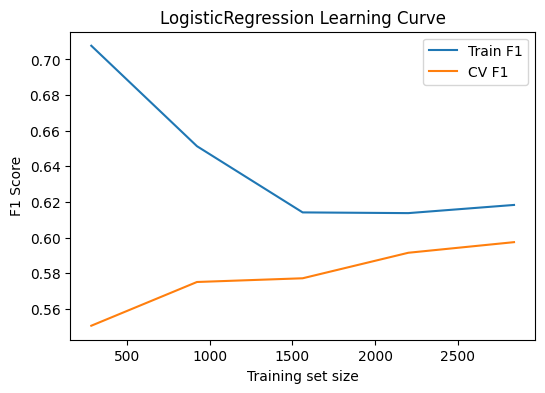


=== RandomForest ===
Best Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
CV F1 Score: 0.6226211271346098
Saved as best_randomforest.pkl


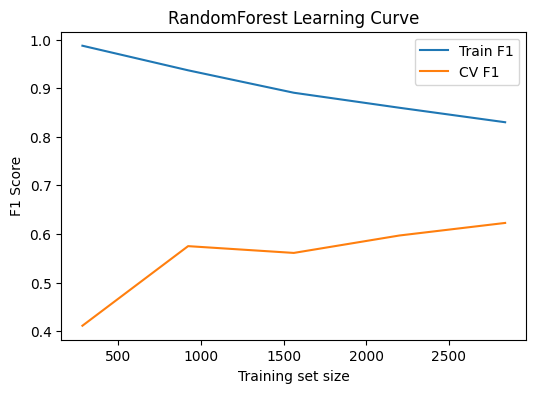

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:55:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost ===
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:55:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:55:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:55:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:55:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:55:37] WARNING: /w

CV F1 Score: 0.6316615211156764
Saved as best_xgboost.pkl


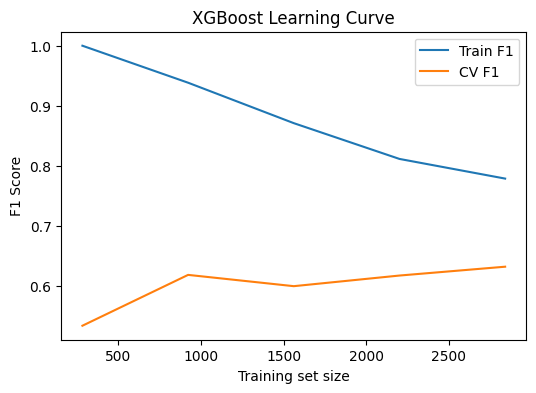

In [ ]:
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

use_smote = False

if use_smote:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print("SMOTE applied → New class distribution:", np.bincount(y_train))
else:
    print("No SMOTE → Class distribution:", np.bincount(y_train))

def train_model(model, param_grid, model_name, plot_learning_curve=False, search_type="grid", n_iter=20):
    if search_type == "grid":
        search = GridSearchCV(model, param_grid, cv=5, scoring='f1', n_jobs=-1)
    elif search_type == "random":
        search = RandomizedSearchCV(model, param_grid, n_iter=n_iter, cv=5, scoring='f1', n_jobs=-1, random_state=42)
    else:
        raise ValueError("search_type must be 'grid' or 'random'")

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    print(f"\n=== {model_name} ===")
    print("Best Params:", search.best_params_)
    cv_score = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1')
    print("CV F1 Score:", np.mean(cv_score))

    joblib.dump(best_model, f"best_{model_name.lower()}.pkl")
    print(f"Saved as best_{model_name.lower()}.pkl")

    if plot_learning_curve:
        train_sizes, train_scores, test_scores = learning_curve(
            best_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5)
        )
        plt.figure(figsize=(6,4))
        plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train F1')
        plt.plot(train_sizes, np.mean(test_scores, axis=1), label='CV F1')
        plt.title(f"{model_name} Learning Curve")
        plt.xlabel("Training set size")
        plt.ylabel("F1 Score")
        plt.legend()
        plt.show()

    return best_model

model_configs = {
    "LogisticRegression": {
        "model": LogisticRegression(random_state=42, class_weight="balanced"),
        "params": {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2'],
            'solver': ['lbfgs'],
            'max_iter': [1000]
        },
        "search_type": "grid"
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42, class_weight="balanced"),
        "params": {
            'n_estimators': [100, 200],
            'max_depth': [None, 5, 10],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        },
        "search_type": "grid"
    },
    "XGBoost": {
        "model": xgb.XGBClassifier(
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss',
            scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train)
        ),
        "params": {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.01, 0.1],
            'subsample': [0.8, 1]
        },
        "search_type": "grid"
    }
    # "LightGBM": { ... }
    # "CatBoost": { ... }
}

best_models = {}
for name, cfg in model_configs.items():
    best_models[name] = train_model(
        cfg["model"], cfg["params"], name, plot_learning_curve=True, search_type=cfg["search_type"]
    )


🔎 Evaluating Logistic Regression...
Logistic Regression → Best Threshold: 0.56, Accuracy: 0.899, Precision: 0.531, Recall: 0.860, F1: 0.656, ROC-AUC: 0.939


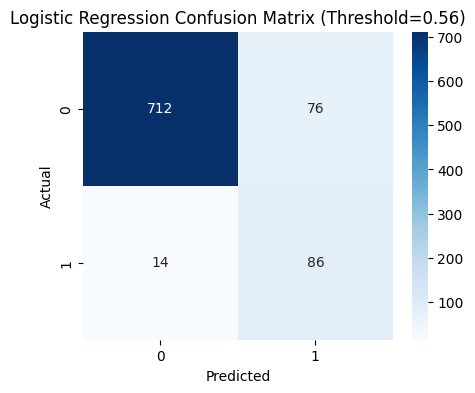

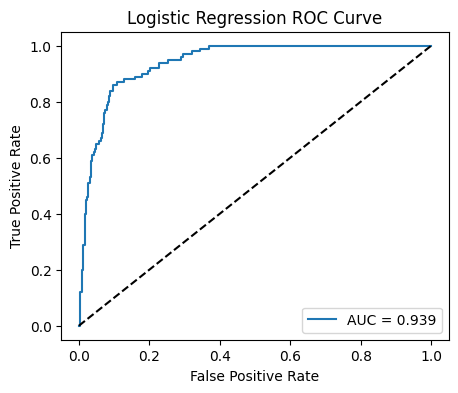

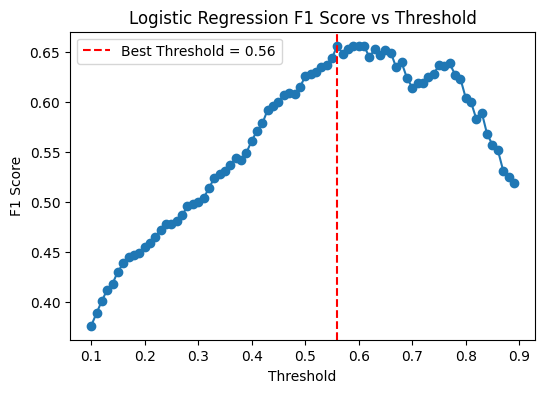


🔎 Evaluating Random Forest...
Random Forest → Best Threshold: 0.43, Accuracy: 0.905, Precision: 0.553, Recall: 0.840, F1: 0.667, ROC-AUC: 0.947


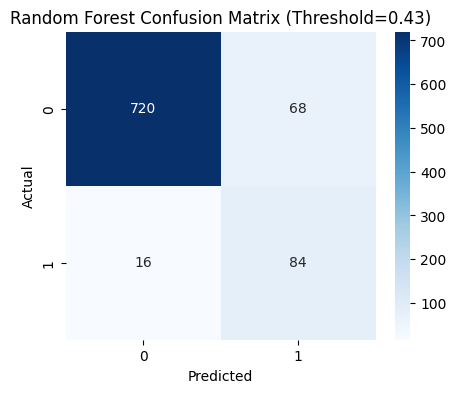

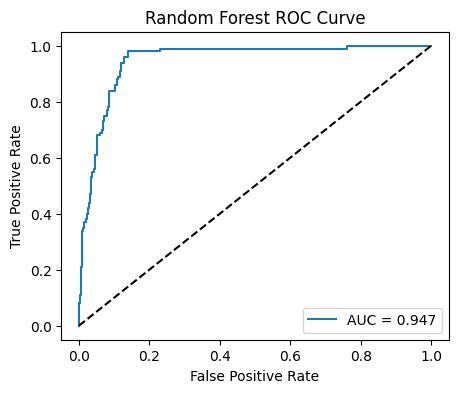

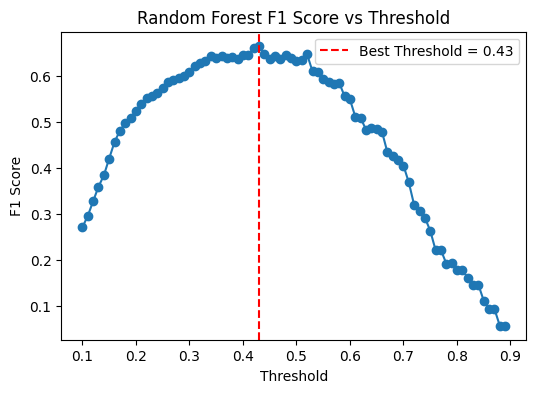


🔎 Evaluating XGBoost...
XGBoost → Best Threshold: 0.45, Accuracy: 0.899, Precision: 0.532, Recall: 0.820, F1: 0.646, ROC-AUC: 0.941


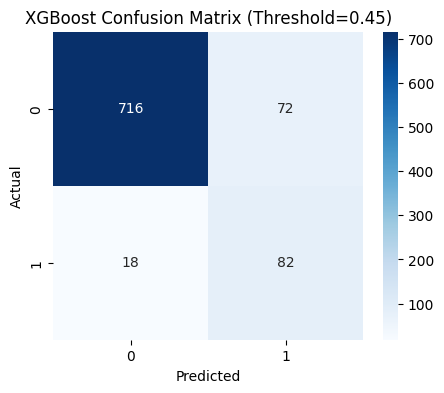

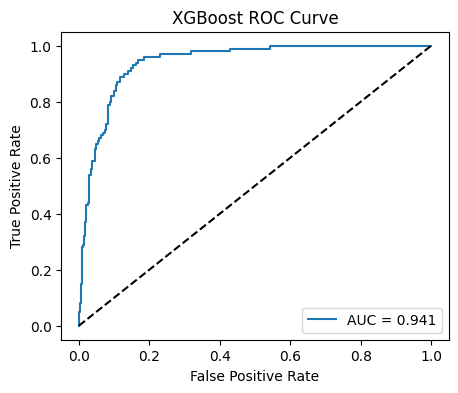

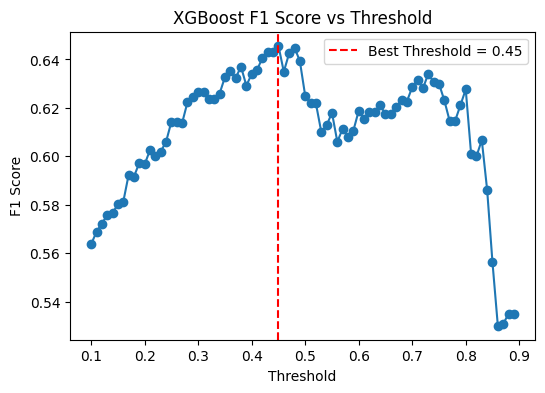


📊 Model Comparison Summary:


,Model,Best Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.56,0.899,0.531,0.86,0.656,0.939
1,Random Forest,0.43,0.905,0.553,0.84,0.667,0.947
2,XGBoost,0.45,0.899,0.532,0.82,0.646,0.941


/tmp/ipython-input-2525761174.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y="Model", data=sorted_df, palette="viridis")


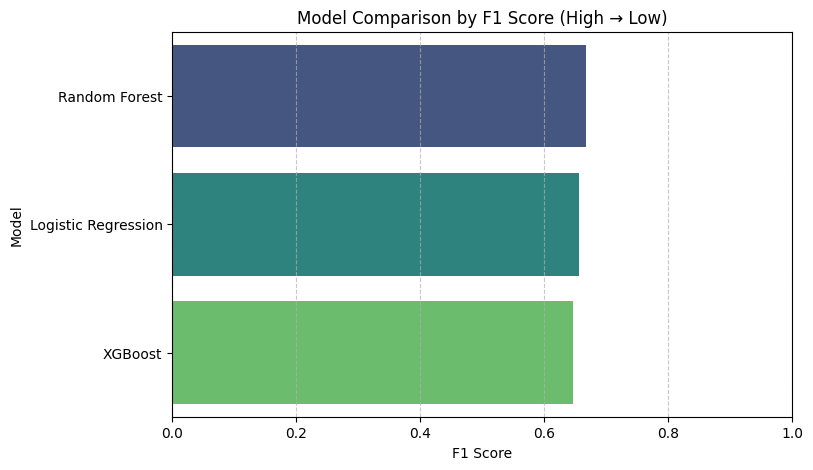

/tmp/ipython-input-2525761174.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y="Model", data=sorted_df, palette="viridis")


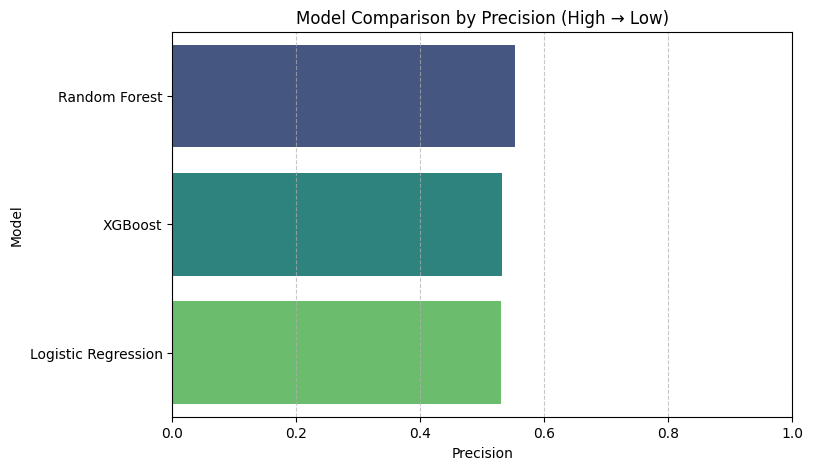

/tmp/ipython-input-2525761174.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y="Model", data=sorted_df, palette="viridis")


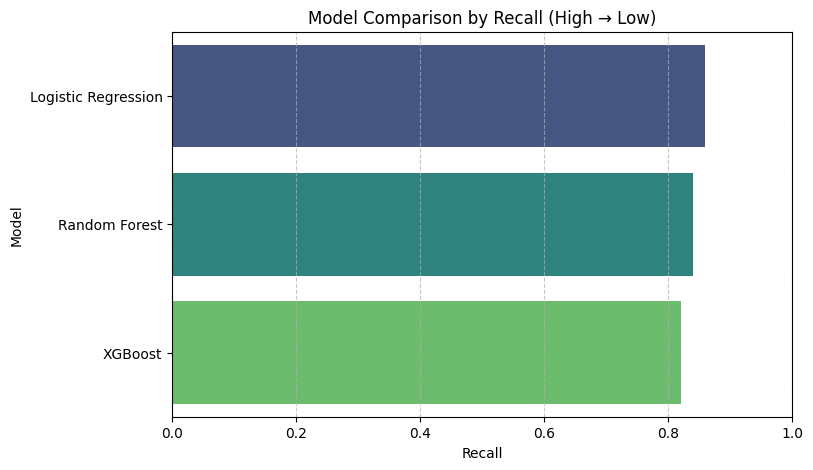

/tmp/ipython-input-2525761174.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y="Model", data=sorted_df, palette="viridis")


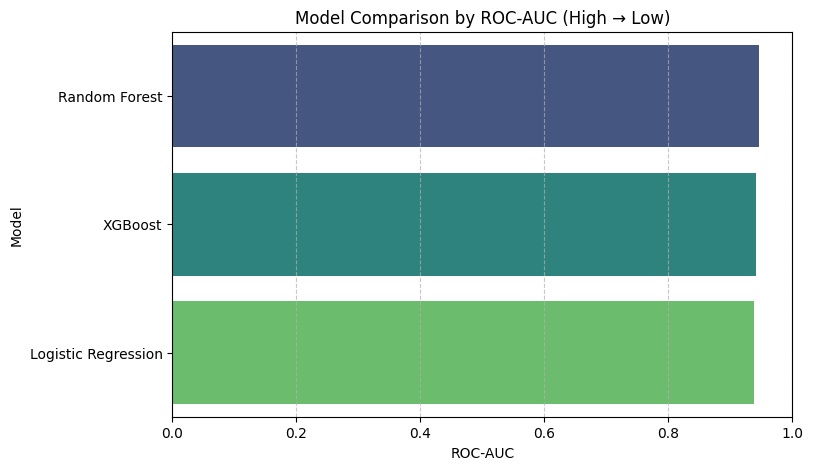

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve
)

best_logreg = joblib.load("best_logisticregression.pkl")
best_rf = joblib.load("best_randomforest.pkl")
best_xgb = joblib.load("best_xgboost.pkl")

models = {
    "Logistic Regression": best_logreg,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
    # "LightGBM": best_lgb,
    # "CatBoost": best_cat
}

thresholds = np.arange(0.1, 0.9, 0.01)
results = []

for name, model in models.items():
    print(f"\n🔎 Evaluating {name}...")

    # Check if model is fitted
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except:
        print(f"⚠️ {name} not fitted. Skipping.")
        continue

    best_f1 = 0
    best_thresh = 0.5
    best_pred = None
    f1_scores = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        f1 = f1_score(y_test, y_pred)
        f1_scores.append(f1)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
            best_pred = y_pred

    acc = accuracy_score(y_test, best_pred)
    prec = precision_score(y_test, best_pred)
    rec = recall_score(y_test, best_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Best Threshold": round(best_thresh, 2),
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1 Score": round(best_f1, 3),
        "ROC-AUC": round(roc_auc, 3)
    })

    print(f"{name} → Best Threshold: {best_thresh:.2f}, "
          f"Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, "
          f"F1: {best_f1:.3f}, ROC-AUC: {roc_auc:.3f}")

    cm = confusion_matrix(y_test, best_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix (Threshold={best_thresh:.2f})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} ROC Curve")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(thresholds, f1_scores, marker='o')
    plt.axvline(best_thresh, color='r', linestyle='--', label=f'Best Threshold = {best_thresh:.2f}')
    plt.title(f"{name} F1 Score vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.show()

results_df = pd.DataFrame(results)
print("\n📊 Model Comparison Summary:")
display(results_df)

metrics_to_plot = ["F1 Score", "Precision", "Recall", "ROC-AUC"]
for metric in metrics_to_plot:
    sorted_df = results_df.sort_values(by=metric, ascending=False).reset_index(drop=True)
    plt.figure(figsize=(8,5))
    sns.barplot(x=metric, y="Model", data=sorted_df, palette="viridis")
    plt.title(f"Model Comparison by {metric} (High → Low)")
    plt.xlabel(metric)
    plt.ylabel("Model")
    plt.xlim(0, 1)
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.show()